# Set-up

In [1]:
import os
from google.colab import userdata

# Get the token from the Secrets pane
github_token = userdata.get('Crecerelle-GitHub-Access')

# Set it as an environment variable for pip
os.environ['Crecerelle-GitHub-Access'] = github_token

# @markdown **Crecerelle:** Install the library from GitHub
#!pip install git+https://{os.environ['Crecerelle-GitHub-Access']}@github.com/fweberling/crecerelle.git
!pip install git+https://{os.environ['Crecerelle-GitHub-Access']}@github.com/fweberling/crecerelle.git "pandas==2.2.2"

  Cloning https://****@github.com/fweberling/crecerelle.git to /tmp/pip-req-build-a0vknpu_
  Running command git clone --filter=blob:none --quiet 'https://****@github.com/fweberling/crecerelle.git' /tmp/pip-req-build-a0vknpu_
  Resolved https://****@github.com/fweberling/crecerelle.git to commit ca08b0649bfecfdd550b1f5c2f8fd9363fc9ec23
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of anndata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scanpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# @markdown **Directory structure:** Set-up the directory structure to store the results of Crecerelle. We recommend connecting to your Google Drive. Otherwise, the directories will be created only temporarily in Colab. If you have already set-up the directory structure from a previous analysis, the existing directories will not be overwritten but only the new ones added.

connect_google_drive = True # @param {type:"boolean"}

if connect_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')

    root_directory = "/content/drive/My Drive"
else:
    root_directory = "/content"





Mounted at /content/drive


The following directory structure is then created:
```text
root_directory/
└── crecerelle_results/
    ├── data/
    │   └── <dataset_name>/  *(optional)*
    ├── figures/
    │   └── <dataset_name>/  *(optional)*
    └── models/
        ├── scGETUVI/
        ├── scTUVI/
        └── scVI/

In [3]:
from crecerelle.utils import setup_crecerelle
import os

# @markdown **Dataset name:** Define the dataset name
dataset_name = "tabulaMuris" # @param

# Set-up the directory structure
setup_crecerelle(root_directory, dataset_name=dataset_name)

# @markdown The working directory is then set to "./crecerelle_results"
if os.path.basename(os.path.normpath(os.getcwd())) != "crecerelle_results":
    os.chdir("drive/My Drive/crecerelle_results")

# Print the working directory
print(f"The working directory is set to: {os.getcwd()}")

Skipped (already exists): /content/drive/My Drive/crecerelle_results
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scTUVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scGETUVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data/tabulaMuris
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures/tabulaMuris
The working directory is set to: /content/drive/My Drive/crecerelle_results


In [4]:
# @markdown **Imports:** modules from PyTorch, Numpy, Scanpy amongst others are imported together with the crecerelle modules necessary for training of scVI and scTUVI
# General import
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from umap import UMAP
import scib
import pandas as pd

# Imports from crecerelle
from crecerelle.cell import TABULA_MURIS_CELL_TYPES, MOUSE_CORTEX_BICCN_CELL_TYPES, TABULA_MURIS_TISSUE_ORGAN_SYSTEM_DICT, TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT
from crecerelle.utils import GeneExpressionDataset, TranscriptUsageDataset, intron_names_2_integers

# Settings for plotting
plt.rcParams.update({
    'font.size': 16,              # General font size
    'axes.labelsize': 16,         # Font size for x and y labels
    'axes.titlesize': 16,         # Font size for subplot titles
    'xtick.labelsize': 16,        # Font size for x-axis tick labels
    'ytick.labelsize': 16,        # Font size for y-axis tick labels
    'legend.fontsize': 16,        # Font size for legend labels
    #'font.family': 'sans-serif',
    #'font.sans-serif': 'Roboto',
    # 'figure.titlesize': 10,    # Font size for the overall figure title (if you use it)
})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Run for work
#import os
#os.chdir("../scASpred")

#!pwd

In [6]:
# @markdown **Specify settings:** These are the general settings for keys to be defined. They are stored in a dictionary called settings. The dataset_name key is already saved in it. The current settings contain the default version for the Tabula Muris dataset.

# @markdown Key of Anndata object specifiying the cell type
settings_cell_type_key = "cell_ontology_class" # @param

# @markdown  Cell types of dataset given
settings_cell_types = TABULA_MURIS_CELL_TYPES # @param

# @markdown Abbreviations of cell types
settings_cell_type_abbreviations = TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT # @param

# @markdown Organisational entity of cell groups (e.g. tissue)
settings_cell_type_groups_key = "tissue" # @param

# @markdown Name of gene annotation file
settings_gene_annotation = "Mus_musculus.GRCm38.102.chr.gtf.gz" # @param

# @markdown Number of highly variable genes selected (HVGs)
settings_num_hvg = 3000 # @param

# @markdown Data partition used (recommended: "full") for tasks
settings_data_type = "full" # @param

# @markdown Key of Anndata object specifying the data partition (e.g. "train", "val", "test)
settings_data_partition_key = "data_partition" # @param

# @markdown Filter data to cell types with a minimum count
settings_filter_cell_types = True # @param {type:"boolean"}

# @markdown Minimum count threshold for filtering if filter_cell_types is True
settings_min_count_threshold = 100 # @param {type:"integer"}

settings = {
    "dataset_name": dataset_name, # Name of dataset
    "cell_type_key": settings_cell_type_key, # Key of Anndata object specifiying the cell type
    "cell_types": settings_cell_types, # Cell types of dataset given
    "cell_type_abbreviations": settings_cell_type_abbreviations, # Abbreviations of cell types
    "cell_type_groups_key": settings_cell_type_groups_key, # Organisational entity of cell groups (e.g. tissue)
    "gene_annotation": settings_gene_annotation,
    "num_hvg": settings_num_hvg, # Number of highly variable genes selected (HVGs)
    "data_type": settings_data_type, # Data partition used (recommended: "full") for tasks
    "data_partition_key": settings_data_partition_key,
    "filter_cell_types": settings_filter_cell_types, # Filter data to cell types with a minimum count
    "min_count_threshold": settings_min_count_threshold, # Minimum count threshold for filtering if filter_cell_types is True
}

In [7]:
# @markdown All data files must be stored here and the resulting new data will also be stored here.
path2data = "./data/" + settings["dataset_name"] + "/"

print(f"The data files will be stored in: {path2data}")

The data files will be stored in: ./data/tabulaMuris/


# Loading of data

Ensure the Anndata objects of the gene expression and transcript usage data are uploaded in "./crecerelle_results/data/dataset_name" *(optional)*. The object containing the gene expression matrix should have the prefix "adata_GE" whereas the one containing the transcript usage matrix should start with "adata_TU". Examples are:




*   adata_GE_{data_type}_preprocessed.h5ad
    *   e.g. adata_GE_full_preprocessed.h5ad
*   adata_TU_{data_type}_preprocessed.h5ad
    *   e.g. adata_TU_full_preprocessed.h5ad
*   adata_GE_{num_hvg}_{data_partition}.h5ad
    *   adata_GE_3000_train.h5ad
    *   adata_GE_3000_val.h5ad
    *   adata_GE_3000_test.h5ad



## Gene expression

Create the dataset of gene expression for inference with scVI

In [ ]:
hvg_annotation = np.load(path2data + settings["data_type"] + "_" + str(settings["num_hvg"]) + "_hvg_annotation.npy")

if settings["data_type"] != "full":
    # Load gene expression data of specified data partition
    adata_GE = ad.read_h5ad(path2data + "adata_GE_full_preprocessed.h5ad")
    adata_GE = adata_GE[:, hvg_annotation].copy()
    adata_GE.obs[settings["data_partition_key"]] = settings["data_type"]

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_GE.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train and adata_GE_val to filtered_cell_types
        adata_GE_filtered = adata_GE[adata_GE.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_GE = adata_GE_filtered

    print(f"Following Anndata object contains the gene expression data of the data partition {settings["data_type"]}: \n {adata_GE}")
else:
    # Load gene expression training data
    adata_GE_train = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_" + "train.h5ad")
    adata_GE_train = adata_GE_train[:, hvg_annotation].copy()
    adata_GE_train.obs[settings["data_partition_key"]] = "train"

    # Load gene expression validation data
    adata_GE_val = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_" + "val.h5ad")
    adata_GE_val = adata_GE_val[:, hvg_annotation].copy()
    adata_GE_val.obs[settings["data_partition_key"]] = "val"

    # Load gene expression test data
    adata_GE_test = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_" + "test.h5ad")
    adata_GE_test = adata_GE_test[:, hvg_annotation].copy()
    adata_GE_test.obs[settings["data_partition_key"]] = "test"

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_GE_train.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train and adata_GE_val to filtered_cell_types
        adata_GE_train_filtered = adata_GE_train[adata_GE_train.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_GE_val_filtered = adata_GE_val[adata_GE_val.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_GE_test_filtered = adata_GE_test[adata_GE_test.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_GE_train = adata_GE_train_filtered
        adata_GE_val = adata_GE_val_filtered
        adata_GE_test = adata_GE_test_filtered

        print(f"Cell types with less than {settings["min_count_threshold"]} have been filtered out. \n")

    adata_GE = ad.concat([adata_GE_train, adata_GE_val, adata_GE_test], axis=0, join="outer", merge="same")

# @markdown **Optional: Filter cells in taxonomy level:** Per taxonomy level, filter out all cell types with less than min_cells (if not set to 0)
min_cells_per_tax_level = 50 # @param {type:"integer"}

if min_cells_per_tax_level > 0:
    # 1. Calculate the size of each cell type group within each tissue
    # transform('size') returns a Series with the same index as the original dataframe
    counts = adata_GE.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')

    # 2. Create a boolean mask for cells to keep
    keep_mask = counts >= min_cells_per_tax_level

    # 3. Slice both AnnData objects in the tuple
    adata_GE_filtered = adata_GE[keep_mask, :].copy()

    adata_GE_filtered.obs[settings["cell_type_key"]] = adata_GE_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()

    adata_GE = adata_GE_filtered.copy()
    adata_GE_train = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "train", :].copy()
    adata_GE_val = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "val", :].copy()
    adata_GE_test = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "test", :].copy()

    print(f"Cell types with less than {min_cells_per_tax_level} cells per taxonomy level have been filtered out. \n")

print(f"Following Anndata object contains the gene expression data of the data partition {settings["data_type"]}: \n {adata_GE}")

# @markdown **Dataset:** Create the dataset of gene expression for inference with scVI
cell_gene_counts = torch.from_numpy(adata_GE.layers["counts"].toarray())
cell_gene_levels = torch.from_numpy(adata_GE.X.toarray())

transform_gene_counts = None
transform_ontology = "one-hot"

gene_expression_dataset = GeneExpressionDataset(
    cell_gene_counts=cell_gene_counts,
    cell_gene_levels=cell_gene_levels,
    ontology=adata_GE.obs[settings["cell_type_key"]].to_numpy(),
    tissue=adata_GE.obs[settings["cell_type_groups_key"]].to_numpy(),
    cell_types=cell_types,
    transform_gene_counts=transform_gene_counts,
    transform_ontology=transform_ontology
)

print(f"The dataset is set up for inference.")

Cell types with less than 100 have been filtered out. 



/tmp/ipykernel_1284/276123788.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_GE.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Cell types with less than 50 cells per taxonomy level have been filtered out. 

Following Anndata object contains the gene expression data of the data partition full: 
 AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'lo

## Transcript usage

Create the dataset of transcript usage for inference with scTUVI

In [ ]:
# Load transcript usage data
if settings["data_type"] != "full":
    adata_TU = ad.read_h5ad(path2data + "adata_TU_full_preprocessed.h5ad")
    intron_groups_by_name = adata_TU.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU.obs[settings["data_partition_key"]] = settings["data_type"]

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_TU.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train and adata_GE_val to filtered_cell_types
        adata_TU_filtered = adata_TU[adata_TU.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_TU = adata_TU_filtered

    print(f"Following Anndata object contains the transcript usage data of the data partition {data_type}: \n {adata_TU}")

else:
    # Load transcript usage training data
    adata_TU_train = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_train.h5ad")
    intron_groups_by_name = adata_TU_train.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU_train.obs[settings["data_partition_key"]] = "train"

    # Load transcript usage validation data
    adata_TU_val = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_val.h5ad")
    adata_TU_val.obs[settings["data_partition_key"]] = "val"

    # Load transcript usage test data
    adata_TU_test = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_test.h5ad")
    adata_TU_test.obs[settings["data_partition_key"]] = "test"

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_TU_train.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train and adata_GE_val to filtered_cell_types
        adata_TU_train_filtered = adata_TU_train[adata_TU_train.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_val_filtered = adata_TU_val[adata_TU_val.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_test_filtered = adata_TU_test[adata_TU_test.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_TU_train = adata_TU_train_filtered
        adata_TU_val = adata_TU_val_filtered
        adata_TU_test = adata_TU_test_filtered

        print(f"Cell types with less than {settings["min_count_threshold"]} have been filtered out. \n")

    adata_TU = ad.concat([adata_TU_train, adata_TU_val, adata_TU_test], axis=0, join="outer", merge="same")

# @markdown **Optional: Filter cells in taxonomy level:** Per taxonomy level, filter out all cell types with less than min_cells (if not set to 0)
min_cells_per_tax_level = 50 # @param {type:"integer"}

if min_cells_per_tax_level > 0:
    # 1. Calculate the size of each cell type group within each tissue
    # transform('size') returns a Series with the same index as the original dataframe
    counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')

    # 2. Create a boolean mask for cells to keep
    keep_mask = counts >= min_cells_per_tax_level

    # 3. Slice both AnnData objects in the tuple
    adata_TU_filtered = adata_TU[keep_mask, :].copy()

    adata_TU_filtered.obs[settings["cell_type_key"]] = adata_TU_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()

    adata_TU = adata_TU_filtered.copy()
    adata_TU_train = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "train", :].copy()
    adata_TU_val = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "val", :].copy()
    adata_TU_test = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "test", :].copy()

    print(f"Cell types with less than {min_cells_per_tax_level} cells per taxonomy level have been filtered out. \n")

print(f"Following Anndata object contains the transcript usage data of the data partition {settings["data_type"]}: \n {adata_TU}")

# Create dataset and dataloader
cell_intron_counts = torch.from_numpy(adata_TU.layers["counts"].toarray())
#cell_intron_levels = torch.from_numpy(adata_TU_train.layers["psi"])
cell_intron_levels = torch.from_numpy(adata_TU.X.toarray())

transform_intron_counts = None # Previously "log" but incorrect
transform_intron_levels = None
transform_ontology = "one-hot"

transcript_usage_dataset = TranscriptUsageDataset(
    cell_intron_counts=cell_intron_counts,
    cell_intron_levels=cell_intron_levels,
    ontology=adata_TU.obs[settings["cell_type_key"]].to_numpy(),
    tissue=adata_TU.obs[settings["cell_type_groups_key"]].to_numpy(),
    cell_types= cell_types,
    transform_intron_counts=transform_intron_counts,
    transform_intron_levels=transform_intron_levels,
    transform_ontology=transform_ontology
)

print(f"The dataset is set up for inference.")

Cell types with less than 100 have been filtered out. 



/tmp/ipykernel_894/3559744410.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Cell types with less than 50 cells per taxonomy level have been filtered out. 

Following Anndata object contains the transcript usage data of the data partition full: 
 AnnData object with n_obs × n_vars = 36256 × 2319
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'data_partition'
    var: 'chromosome', 'start', 'end', 'strand', 'annotated', 'gene_id_start', 'gene_id_end', 'n_genes', 'gene_id', 'gene_name', 'intron_group', 'intron_group_size', 'n_genes_per_intron_group'
    layers: 'counts', 'psi'
The dataset is set up for inference.


# Models

In [ ]:
# @markdown **Dimension of latent space:** Define the dimensionality of the cell embeddings
latent_dim = 10 # @param {type:"integer"}

# @markdown **Beta parameter:** Choose the value for the beta parameter
beta = 1.0 # @param {type:"number"}

# @markdown **Architecture of neural networks:** choose the number of hidden layers as well as the number of hidden units per layer for the encoding and decoding neural networks
num_hidden_layers = 2 # @param {type:"integer"}
num_hidden_units = 256 # @param {type:"integer"}

# @markdown **Dropout rate:** If dropout shall be applied, set the dropout rate to 0.0 > p > 1.0. Otherwise, choose 0.0.
dropout_rate = 0.1 # @param {type:"number"}
scaling_factor = True # @param {type:"boolean"}
device = "cuda" # @param ["cuda", "cpu"]

# Convert beta to string
beta_str = f"{beta:.1f}"
beta_str = beta_str.replace(".", "")
while len(beta_str) < 3:
    beta_str = "0" + beta_str

## Gene expression scVI

In [ ]:
# @markdown Install scvi-tools package to use the trained scVI model for gene expression data
!pip install scvi-tools

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.1/699.1 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 67.4 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=8f583cbf0f9cac4fcc41727776200ce6cb02eea191153a4fa6b8cf5f5d03ca91
  Stored in directory: /root/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52

In [ ]:
# @markdown **Path to models:** Set the path to the trained models
settings_path2models = "./models/scVI/" # @param
settings["path2models"] = settings_path2models
print(f"The scVI models trained are chosen from the path {settings["path2models"]}")

The scVI models trained are chosen from the path ./models/scVI/


In [ ]:
import scvi

# @markdown Load the trained scVI model
model = scvi.model.SCVI.load(settings["path2models"], adata=adata_GE)

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/mudata/__init__.py:30: DeprecationWarning: The decorator_name argument is deprecated and will be removed in the future.
  register_mudata_namespace = _make_register_namespace_decorator(MuData, "mdata", "register_mudata_namespace", "numpy")
/usr/local/lib/python3.12/dist-packages/mudata/__init__.py:30: DeprecationWarning: The docstring_style argument is deprecated and will be removed in the future.
  register_mudata_na

INFO     File ./models/scVI/model.pt already downloaded                                                            


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Transcript usage scTUVI with Dirichlet-Multinomial observation model

In [ ]:
# @markdown **Path to models:** Set the path to the trained models
settings_path2models = "./models/scTUVI/" # @param
settings["path2models"] = settings_path2models
print(f"The scTUVI models trained are chosen from the path {settings["path2models"]}")

The scTUVI models trained are chosen from the path ./models/scTUVI/


In [ ]:
from crecerelle.models import DMTranscriptUsageVAE

model = DMTranscriptUsageVAE(
    input_dim=transcript_usage_dataset.num_introns,
    num_intron_groups=num_intron_groups,
    intron_groups = intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    dropout_rate=dropout_rate,
    device=device,
    scaling_factor=False # by default
)

# @markdown **Observation model of scTUVI:** Dirichlet-Multinomial (DM) likelihood
likelihood_type = "DM"
count_data_included = True

# @markdown **Random seed:** select the random seed
seed = 5 # @param {type:"integer"} 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
torch.manual_seed(seed)
np.random.seed(seed)

# Nomenclature scTUVI + likelihood + seed + beta
model_name = "scTUVI_" + likelihood_type + "_" + str(seed) + "_Beta_" + beta_str
loss_type = "VariationalELBO"

# @markdown **Model checkpoint:** Specify the model checkpoint you want to load for inference
epoch_checkpoint = 99 # @param {type:"integer"}

model_checkpoint = model_name + "_epochs_" + str(epoch_checkpoint) + "_checkpoint.pth"
checkpoint = torch.load(settings["path2models"] + settings["dataset_name"] + "_" + str(settings["num_hvg"]) + "_" + model_checkpoint, map_location=torch.device(device))
model.load_state_dict(checkpoint["model_state_dict"])

# Push model to GPU if available
if torch.cuda.is_available():
    model = model.to(device)

/usr/local/lib/python3.12/dist-packages/crecerelle/models.py:1367: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  torch.sparse_coo_tensor(


## Transcript usage scTUVI with zero-and-N-inflated Dirichlet-Multinomial ZANIDM observation model

In [ ]:
# @markdown **Path to models:** Set the path to the trained models
settings_path2models = "./models/scTUVI/" # @param
settings["path2models"] = settings_path2models
print(f"The scTUVI models trained are chosen from the path {settings["path2models"]}")

The scTUVI models trained are chosen from the path ./models/scTUVI/


In [ ]:
from crecerelle.models import ZANIDMTranscriptUsageVAE
model = ZANIDMTranscriptUsageVAE(
    input_dim=transcript_usage_dataset.num_introns,  # number of introns
    num_intron_groups=num_intron_groups,
    intron_groups=intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    dropout_rate=dropout_rate,
    device=device
)



# @markdown **Observation model of scTUVI:** Zero-and-N-inflated Dirichlet-Multinomial (ZANIDM) likelihood
likelihood_type = "ZANIDM"
count_data_included = True

# @markdown **Random seed:** select the random seed
seed = 6 # @param {type:"integer"} 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
torch.manual_seed(seed)
np.random.seed(seed)

# Nomenclature scTUVI + likelihood + seed + beta
model_name = "scTUVI_" + likelihood_type + "_" + str(seed) + "_Beta_" + beta_str
loss_type = "VariationalELBO"

# @markdown **Model checkpoint:** Specify the model checkpoint you want to load for inference
epoch_checkpoint = 22 # @param {type:"integer"}

model_checkpoint = model_name + "_epochs_" + str(epoch_checkpoint) + "_checkpoint.pth"
checkpoint = torch.load(settings["path2models"] + settings["dataset_name"] + "_" + str(settings["num_hvg"]) + "_" + model_checkpoint, map_location=torch.device(device))
model.load_state_dict(checkpoint["model_state_dict"])

# Push model to GPU if available
if torch.cuda.is_available():
    model = model.to(device)

## Transcript usage scTUVI with ZANIDM heuristic (ZIDM)

In [ ]:
# @markdown **Path to models:** Set the path to the trained models
settings_path2models = "./models/scTUVI/" # @param
settings["path2models"] = settings_path2models
print(f"The scTUVI models trained are chosen from the path {settings["path2models"]}")

The scTUVI models trained are chosen from the path ./models/scTUVI/


In [ ]:
from crecerelle.models import ZIDMTranscriptUsageVAE

model = ZIDMTranscriptUsageVAE(
    input_dim=transcript_usage_dataset.num_introns,  # number of introns
    num_intron_groups=num_intron_groups,
    intron_groups=intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    dropout_rate=dropout_rate,
    device=device
)


# @markdown **Observation model of scTUVI:** ZANIDM heuristic (ZIDM)
likelihood_type = "ZIDM"
count_data_included = True

# @markdown **Random seed:** select the random seed
seed = 1 # @param {type:"integer"} 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
torch.manual_seed(seed)
np.random.seed(seed)

# Nomenclature scTUVI + likelihood + seed + beta
model_name = "scTUVI_" + likelihood_type + "_" + str(seed) + "_Beta_" + beta_str
loss_type = "VariationalELBO"

# @markdown **Model checkpoint:** Specify the model checkpoint you want to load for inference
epoch_checkpoint = 118 # @param {type:"integer"} 19


model_checkpoint = model_name + "_epochs_" + str(epoch_checkpoint) + "_checkpoint.pth"
checkpoint = torch.load(settings["path2models"] + settings["dataset_name"] + "_" + str(settings["num_hvg"]) + "_" + model_checkpoint, map_location=torch.device(device))
model.load_state_dict(checkpoint["model_state_dict"])

# Push model to GPU if available
if torch.cuda.is_available():
    model = model.to(device)

# Inference with chosen model

In [ ]:
from crecerelle.utils import inference_vae
# @markdown The following model is chosen for inference:
print(model)

SCVI model with the following parameters: 
n_hidden: 256, n_latent: 10, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

## Gene expression data

In [ ]:
# @markdown **Inference with chosen scVI:** The trained scVI is used to infer gene expression cell embeddings on the specified dataset
latent_means = model.get_latent_representation()
adata_GE.obsm["ZINB_latent_mean"] = latent_means

adata_GE.obsm["ZINB_X_umap"] = UMAP(n_components=2).fit_transform(adata_GE.obsm["ZINB_latent_mean"])

print(f"The gene expression cell embeddings inferred with scVI are stored in: \n {adata_GE}")

The gene expression cell embeddings inferred with scVI are stored in: 
 AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition', '_scvi_batch', '_scvi_labels'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispers

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# @markdown Tick the box if you want to save the inferred uni-modal cell embeddings with the data as a new AnnData object and the dataframe containing the clustering evaluation.
save_inferred_data = True # @param {type:"boolean"}

if save_inferred_data:
    if settings["data_type"] != "full":
        adata_GE.write(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_" + settings["data_type"] + "_vae_inference.h5ad")
        """
        if tissue is None:
            cluster_eval_df.to_csv(path2data + "cluster_eval_GE_" + data_type + "_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        else:
            cluster_eval_df.to_csv(path2data + "cluster_eval_GE_" + tissue + "_" + data_type + "_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        """
    else:
        adata_GE.write(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_vae_inference.h5ad")
        """
        if tissue is None:
            cluster_eval_df.to_csv(path2data + "cluster_eval_GE_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        else:
            cluster_eval_df.to_csv(path2data + "cluster_eval_GE_" + tissue + "_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        """

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Transcript usage

In [ ]:
# @markdown **Inference with chosen scTUVI:** The trained scTUVI is used to infer uni-modal cell embeddings of transcript usage on the specified dataset
adata_TU = inference_vae(
    adata_TU,
    transcript_usage_dataset,
    model,
    likelihood_type,
    "Transcript usage",
    True,
    256
)

print(f"Following Anndata object contains the transript usage data and inferences of the data partition {settings["data_type"]}: \n {adata_TU}")

Following Anndata object contains the transript usage data and inferences of the data partition full: 
 AnnData object with n_obs × n_vars = 36256 × 2319
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'data_partition', 'DM_nll', 'ZIDM_nll', 'ZANIDM_nll'
    var: 'chromosome', 'start', 'end', 'strand', 'annotated', 'gene_id_start', 'gene_id_end', 'n_genes', 'gene_id', 'gene_name', 'intron_group', 'intron_group_size', 'n_genes_per_intron_group'
    obsm: 'DM_latent_mean', 'DM_X_umap', 'ZIDM_latent_mean', 'ZIDM_X_umap', 'ZANIDM_latent_mean', 'ZANIDM_X_umap'
    layers: 'counts', 'psi', 'DM_reconstructions', 'ZIDM_reconstructions', 'ZANIDM_reconstructions'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# @markdown Tick the box if you want to save the inferred transcript usage cell embeddings with the data as a new AnnData object.
save_inferred_data = True # @param {type:"boolean"}

if save_inferred_data:
    if settings["data_type"] != "full":
        adata_TU.write(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_" + settings["data_type"] + "_vae_inference.h5ad")
        """
        if tissue is None:
            if all_likelihoods:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_" + data_type + "_all_likelihoods_vae_inference.csv", index=False)
            else:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_" + data_type + "_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        else:
            if all_likelihoods:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_" + tissue + "_" + data_type + "_all_likelihoods_vae_inference.csv", index=False)
            else:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_" + tissue + "_" + data_type + "_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        """
    else:
        adata_TU.write(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_vae_inference.h5ad")
        """
        if tissue is None:
            if all_likelihoods:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_all_likelihoods_vae_inference.csv", index=False)
            else:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        else:
            if all_likelihoods:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_" + tissue + "_all_likelihoods_vae_inference.csv", index=False)
            else:
                cluster_eval_df.to_csv(path2data + "cluster_eval_TU_" + tissue + "_" + likelihood_1 + "_" + likelihood_2 + "_vae_inference.csv", index=False)
        """

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Inference results

Load the AnnData objects containing the inferred data. The objects should follow the naming convention:

*   adata_GE_{num_hvg}_vae_inference.h5ad
*   adata_TU_{num_hvg}_vae_inference.h5ad



In [8]:
# @markdown **Data partition:** Select the data partition from which you want to analyse the inference results
data_partition = "full" # @param ["train", "val", "test", "train-test", "full"]

# @markdown **Random seed:** select the random seed (choose 0 for reproducing the results of the paper)
seed = 1 # @param {type:"integer"} 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
torch.manual_seed(seed)
np.random.seed(seed)
settings["seed"] = seed

# Load full dataset
adata_GE = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_vae_inference.h5ad")
adata_TU = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_vae_inference.h5ad")

if data_partition == "train":
    adata_GE = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "train"].copy()
    adata_TU = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "train"].copy()
elif data_partition == "val":
    adata_GE = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "val"].copy()
    adata_TU = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "val"].copy()
elif data_partition == "test":
    adata_GE = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "test"].copy()
    adata_TU = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "test"].copy()
elif data_partition == "train-test":
    adata_GE = adata_GE[adata_GE.obs[settings["data_partition_key"]].isin(["train", "test"])].copy()
    adata_TU = adata_TU[adata_TU.obs[settings["data_partition_key"]].isin(["train", "test"])].copy()
elif data_partition == "full":
    pass
else:
    raise ValueError("Invalid data partition")

# Rename cells in .obs["cell_ontology_class"] according to cell type abbreviation dict
if settings["cell_type_abbreviations"] != None:
    adata_GE.obs[settings["cell_type_key"]] = adata_GE.obs[settings["cell_type_key"]].map(settings["cell_type_abbreviations"])
    adata_TU.obs[settings["cell_type_key"]] = adata_TU.obs[settings["cell_type_key"]].map(settings["cell_type_abbreviations"])

# Group into Organ systems: Map adata_GE.obs["tissue"] to organ systems according to organ system dictionary
if settings["dataset_name"] == "tabulaMuris":
    adata_GE.obs["organ_system"] = adata_GE.obs[settings["cell_type_groups_key"]].map(TABULA_MURIS_TISSUE_ORGAN_SYSTEM_DICT)
    adata_TU.obs["organ_system"] = adata_TU.obs[settings["cell_type_groups_key"]].map(TABULA_MURIS_TISSUE_ORGAN_SYSTEM_DICT)

# Create a tuple of gene expression and transcript usage AnnData objects
adata = (adata_GE, adata_TU)

print(f"Following inferred gene expression data have been loaded: \n {adata_GE} \n")
print(f"Following inferred transcript usage data have been loaded: \n {adata_TU}")

Following inferred gene expression data have been loaded: 
 AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition', '_scvi_batch', '_scvi_labels', 'organ_system'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Robust cell embeddings inferred from single-cell splicing through scTUVI

Compare the gene expression cell embeddings inferred by **scVI** with the transcript usage cell embeddings inferred by **scTUVI** on the dataset provided. For scTUVI, cell embeddings were learnt with a standard **Dirichlet-Multinomial (DM)** observation model as well as with the novel **zero-and-N-inflated Dirichlet-Multinomial (ZANIDM)** observation model and its heuristic approximation the **zero-inflated Dirichlet-Multinomial (ZIDM)**. The **cell embeddings of scVI** as well as **scTUVI-DM, scTUVI-ZANIDM,** and **scTUVI-ZIDM** are **displayed** in 2D using uniform manifold approximation (**UMAP**) projections. To evaluate the four models on recovering the cell type identity, the **biological conservation metrics (NMI, ARI, ASW, and AvgBIO)** are plotted as bar chart.

In [ ]:
# @markdown **Filter cells in taxonomy level:** Per taxonomy level, filter out all cell types with less than min_cells
min_cells_per_tax_level = 50 # @param {type:"integer"}

if min_cells_per_tax_level > 0:
    # 1. Calculate the size of each cell type group within each tissue
    # transform('size') returns a Series with the same index as the original dataframe
    counts = adata_GE.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')

    # 2. Create a boolean mask for cells to keep
    keep_mask = counts >= min_cells_per_tax_level

    # 3. Slice both AnnData objects in the tuple
    adata_GE_filtered = adata[0][keep_mask, :].copy()
    adata_TU_filtered = adata[1][keep_mask, :].copy()

    adata_GE_filtered.obs[settings["cell_type_key"]] = adata_GE_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()
    adata_TU_filtered.obs[settings["cell_type_key"]] = adata_TU_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()

    adata_GE = adata_GE_filtered.copy()
    adata_TU = adata_TU_filtered.copy()

print(f"Following inferred gene expression data have been loaded: \n {adata_GE} \n")
print(f"Following inferred transcript usage data have been loaded: \n {adata_TU}")

/tmp/ipykernel_808/922042316.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_GE.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Following inferred gene expression data have been loaded: 
 AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition', '_scvi_batch', '_scvi_labels', 'organ_system'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dis

The dataset is set up for evaluation.
Case all nonzero: The number of case x_j > 0 and N > 0 is 194844. 
Case all zero: The number of case x = 0 and N = 0 is 34208475. 
Case one nonzero: The number of case d - 1 categories are zero and N > 0 is 2677906. 
Case subsets are zero: The number of case d - 2 categories are zero and N > 0 is 117431.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarni

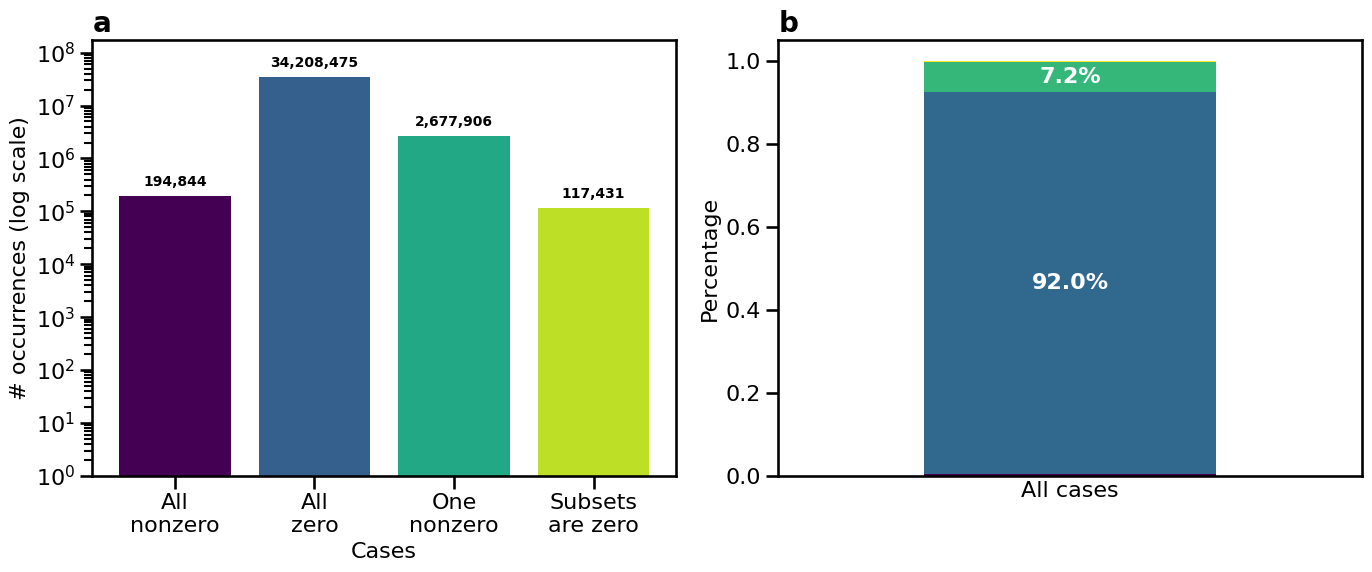

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# @markdown **Modeling splicing data:** Evaluate the number of occurences of the different splicing modeling cases in the dataset given. Two plots are generated with the first one showing the absolute numbers per case as bar chart with the option to display them on a log scale, and with the second one showing the relative occurenes as a stacked bar chart.
from crecerelle.utils import determine_zanidm_cases

num_cases_dict = determine_zanidm_cases(
    adata=adata_TU,
    cell_type_key=settings["cell_type_key"],
    cell_type_groups_key=settings["cell_type_groups_key"]
)

# @markdown **Scale:** Single-cell splicing data are sparse (zero-inflated). Thus it can be helpful to visualise the cases on a log-scale
log_scale = True # @param {type:"boolean"}

# @markdown **Save figure:** save the box plot visualising the different splicing modeling cases

save_fig = True # @param {type:"boolean"}

from crecerelle.plotting_utils import plot_zanidm_cases

plot_zanidm_cases(
    num_cases_dict,
    log_scale,
    save_fig,
    dataset_name=settings["dataset_name"]
)



In [ ]:
# @markdown **Latent space comparison of scTUVI-ZANIDM and scTUVI-ZIDM:** To showcase that ZIDM is an approximation to the ZANIDM, we analyse the distance matrix of the learnt cell embeddings with scTUVI-ZANIDM and with scTUVI-ZIDM. Both matrices are visualised as heatmaps. One can choose between the average cell embedding of each cluster or downsampled version of the full dataset.

average_embeddings = True # @param {type:"boolean"}

downsampling_fraction = 0.1 # @param
if average_embeddings == False:
    # 1. Define your downsampling fraction (10% = 0.1)
    fraction = 0.1

    # 2. Use pandas to sample indices stratified by cell type
    # We group by the cell type column and sample 10% from each group
    sampled_indices = adata_TU.obs.groupby("cell_ontology_class", group_keys=False).apply(
        lambda x: x.sample(frac=fraction, random_state=0)
    ).index

    # 3. Subset the AnnData object using the sampled indices
    adata_TU_downsampled = adata_TU[sampled_indices].copy()

    # 4. Verify the results
    print(f"Original size: {adata_TU.n_obs}")
    print(f"Downsampled size: {adata_TU_downsampled.n_obs}")

# Compute the distance matrices
from crecerelle.utils import distance_matrix

emb_distance_matrix_zanidm, cluster_annotations_zanidm = distance_matrix(
      adata_TU,
      "ZANIDM_latent_mean",
      settings["cell_type_key"],
      average_embeddings = average_embeddings
)

print(f"The distance matrices for scTUVI-ZANIDM of shape: {emb_distance_matrix_zanidm.shape} has been computed.")

emb_distance_matrix_zidm, cluster_annotations_zidm = distance_matrix(
      adata_TU,
      "ZIDM_latent_mean",
      settings["cell_type_key"],
      average_embeddings = average_embeddings
)
print(f"The distance matrices for scTUVI-ZANIDM of shape: {emb_distance_matrix_zanidm.shape} has been computed.")



Averaging embeddings
The distance matrices for scTUVI-ZANIDM of shape: (55, 55) has been computed.
Averaging embeddings
The distance matrices for scTUVI-ZANIDM of shape: (55, 55) has been computed.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backend_pdf.py:1761: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


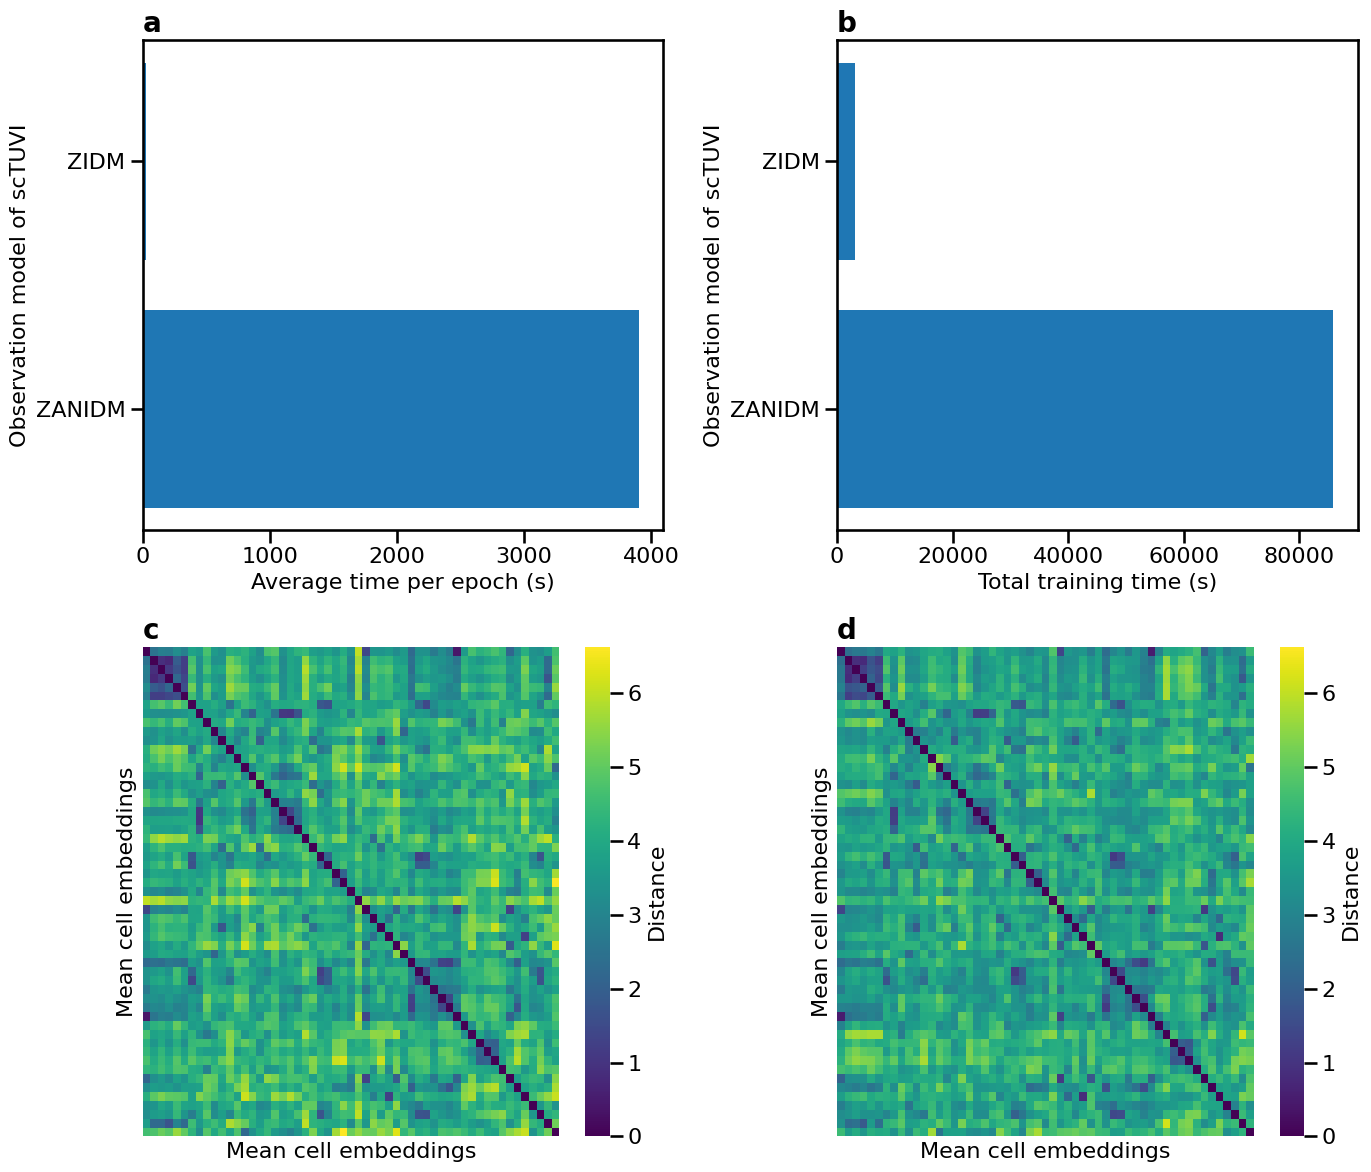

In [ ]:
# @markdown **Comparison of scTUVI-ZANIDM and scTUVI-ZIDM:** Both models are compared by considering the training time per epoch which must have been stopped during training, the total training time, and the heatmaps of the distance matrices of the learnt cell embeddings. The figure is saved if save_fig is set.

avg_time_per_epoch_zanidm = 3900 # @param
avg_time_per_epoch_zidm = 27 # @param
total_time_zanidm = 85800 # @param
total_time_zidm = 3186 # @param

computation_times = {
    "ZANIDM" : {
        "Average time per epoch" : avg_time_per_epoch_zanidm,
        "Total training time" : total_time_zanidm
    },
    "ZIDM" : {
        "Average time per epoch" : avg_time_per_epoch_zidm,
        "Total training time" : total_time_zidm
    }
}

save_fig = True # @param {type:"boolean"}

from crecerelle.plotting_utils import plot_comparison_sctuvi_zanidm_zidm

distance_matrices = (emb_distance_matrix_zanidm, emb_distance_matrix_zidm)
cluster_annotations = (cluster_annotations_zanidm, cluster_annotations_zidm)

plot_comparison_sctuvi_zanidm_zidm(
        distance_matrices = distance_matrices,
        cluster_annotations = cluster_annotations,
        computation_times = computation_times,
        save_fig = save_fig,
        dataset_name = settings["dataset_name"],
        average_embeddings = average_embeddings
)





In [ ]:
  # @markdown **Observation model of gene expression:** Specify the observation model (ZINB, NB) that was used for inference with scVI:
likelihood_GE = "ZINB" # @param ["NB", "ZINB"] (NOW scVI with ZINB)

likelihoods_TU = ["DM", "ZANIDM", "ZIDM"]

likelihood_keys = [likelihood_GE] + likelihoods_TU

# @markdown **Resolutions for Leiden algorithm:** Choose the resolutions for the gene expression data, the transcript usage data with a DM observation model, the transcript usage data with a ZANIDM observation model and, and the transcript usage data with a ZIDM observation model. The defaults for the Tabula Muris dataset are displayed:
# Calculate NMI, ARI, ASW, AvgBio for model
res_GE = 0.6 # @param {type: "number"}
res_DM = 1.4 # @param {type: "number"}
res_ZANIDM = 0.9 # @param {type: "number"}
res_ZIDM = 0.9 # @param {type: "number"}

resolutions = [res_GE, res_DM, res_ZANIDM, res_ZIDM] # GE, DM, ZANIDM, ZIDM
nmi_list = []
ari_list = []
asw_list = []
avg_bio_list = []

sc.pp.neighbors(adata_GE, use_rep=likelihood_GE + "_latent_mean")
leiden_res_GE = "leiden_res_" + str(resolutions[0])
sc.tl.leiden(adata_GE, key_added=leiden_res_GE, resolution=resolutions[0], flavor="igraph")

nmi_score = scib.me.nmi(adata_GE, cluster_key=leiden_res_GE, label_key=settings["cell_type_key"])
asw_score = scib.me.silhouette(adata_GE, label_key=settings["cell_type_key"],
                                       embed=likelihood_GE + "_latent_mean")
ari_score = scib.me.ari(adata_GE, cluster_key=leiden_res_GE, label_key=settings["cell_type_key"])
avg_bio_score = (nmi_score + asw_score + ari_score) / 3

nmi_list.append(nmi_score)
ari_list.append(ari_score)
asw_list.append(asw_score)
avg_bio_list.append(avg_bio_score)

for i, likelihood_TU in enumerate(likelihoods_TU):
    sc.pp.neighbors(adata_TU, use_rep=likelihood_TU + "_latent_mean")
    leiden_res_TU = "leiden_res_" + str(resolutions[i+1])
    sc.tl.leiden(adata_TU, key_added=leiden_res_TU, resolution=resolutions[i+1], flavor="igraph")

    nmi_score = scib.me.nmi(adata_TU, cluster_key=leiden_res_TU, label_key=settings["cell_type_key"])
    asw_score = scib.me.silhouette(adata_TU, label_key=settings["cell_type_key"], embed=likelihood_TU + "_latent_mean")
    ari_score = scib.me.ari(adata_TU, cluster_key=leiden_res_TU, label_key=settings["cell_type_key"])
    avg_bio_score = (nmi_score + asw_score + ari_score) / 3

    nmi_list.append(nmi_score)
    ari_list.append(ari_score)
    asw_list.append(asw_score)
    avg_bio_list.append(avg_bio_score)

# Create an evaluation dataframe
score_values = np.concatenate((np.array(nmi_list), np.array(ari_list), np.array(asw_list), np.array(avg_bio_list)))
if len(likelihood_keys) == 1:
    score_names = np.array(["NMI", "ARI", "ASW", "Avg Bio"])
else:
    score_nmi_names = ["NMI"] * len(likelihood_keys)
    score_ari_names = ["ARI"] * len(likelihood_keys)
    score_asw_names = ["ASW"] * len(likelihood_keys)
    score_avg_bio_names = ["Avg Bio"] * len(likelihood_keys)

    score_names = np.array(score_nmi_names + score_ari_names + score_asw_names + score_avg_bio_names)
likelihood_names = np.array((likelihood_keys * 4))

evaluation_df = pd.DataFrame(
        {
            "Score value": score_values,
            "Evaluation score": score_names,
            "Likelihood": likelihood_names
        }
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# @markdown Save evaluation data as csv
save_eval_df = True # @param {type:"boolean"}

if save_eval_df:
    evaluation_df.to_csv(path2data + "scvi_sctuvi_evaluation_df.csv", index=False)

evaluation_df

,Score value,Evaluation score,Likelihood
0,0.879005,NMI,ZINB
1,0.322856,NMI,DM
2,0.870925,NMI,ZANIDM
3,0.864374,NMI,ZIDM
4,0.684783,ARI,ZINB
5,0.128114,ARI,DM
6,0.714692,ARI,ZANIDM
7,0.723747,ARI,ZIDM
8,0.618557,ASW,ZINB
9,0.456066,ASW,DM


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/

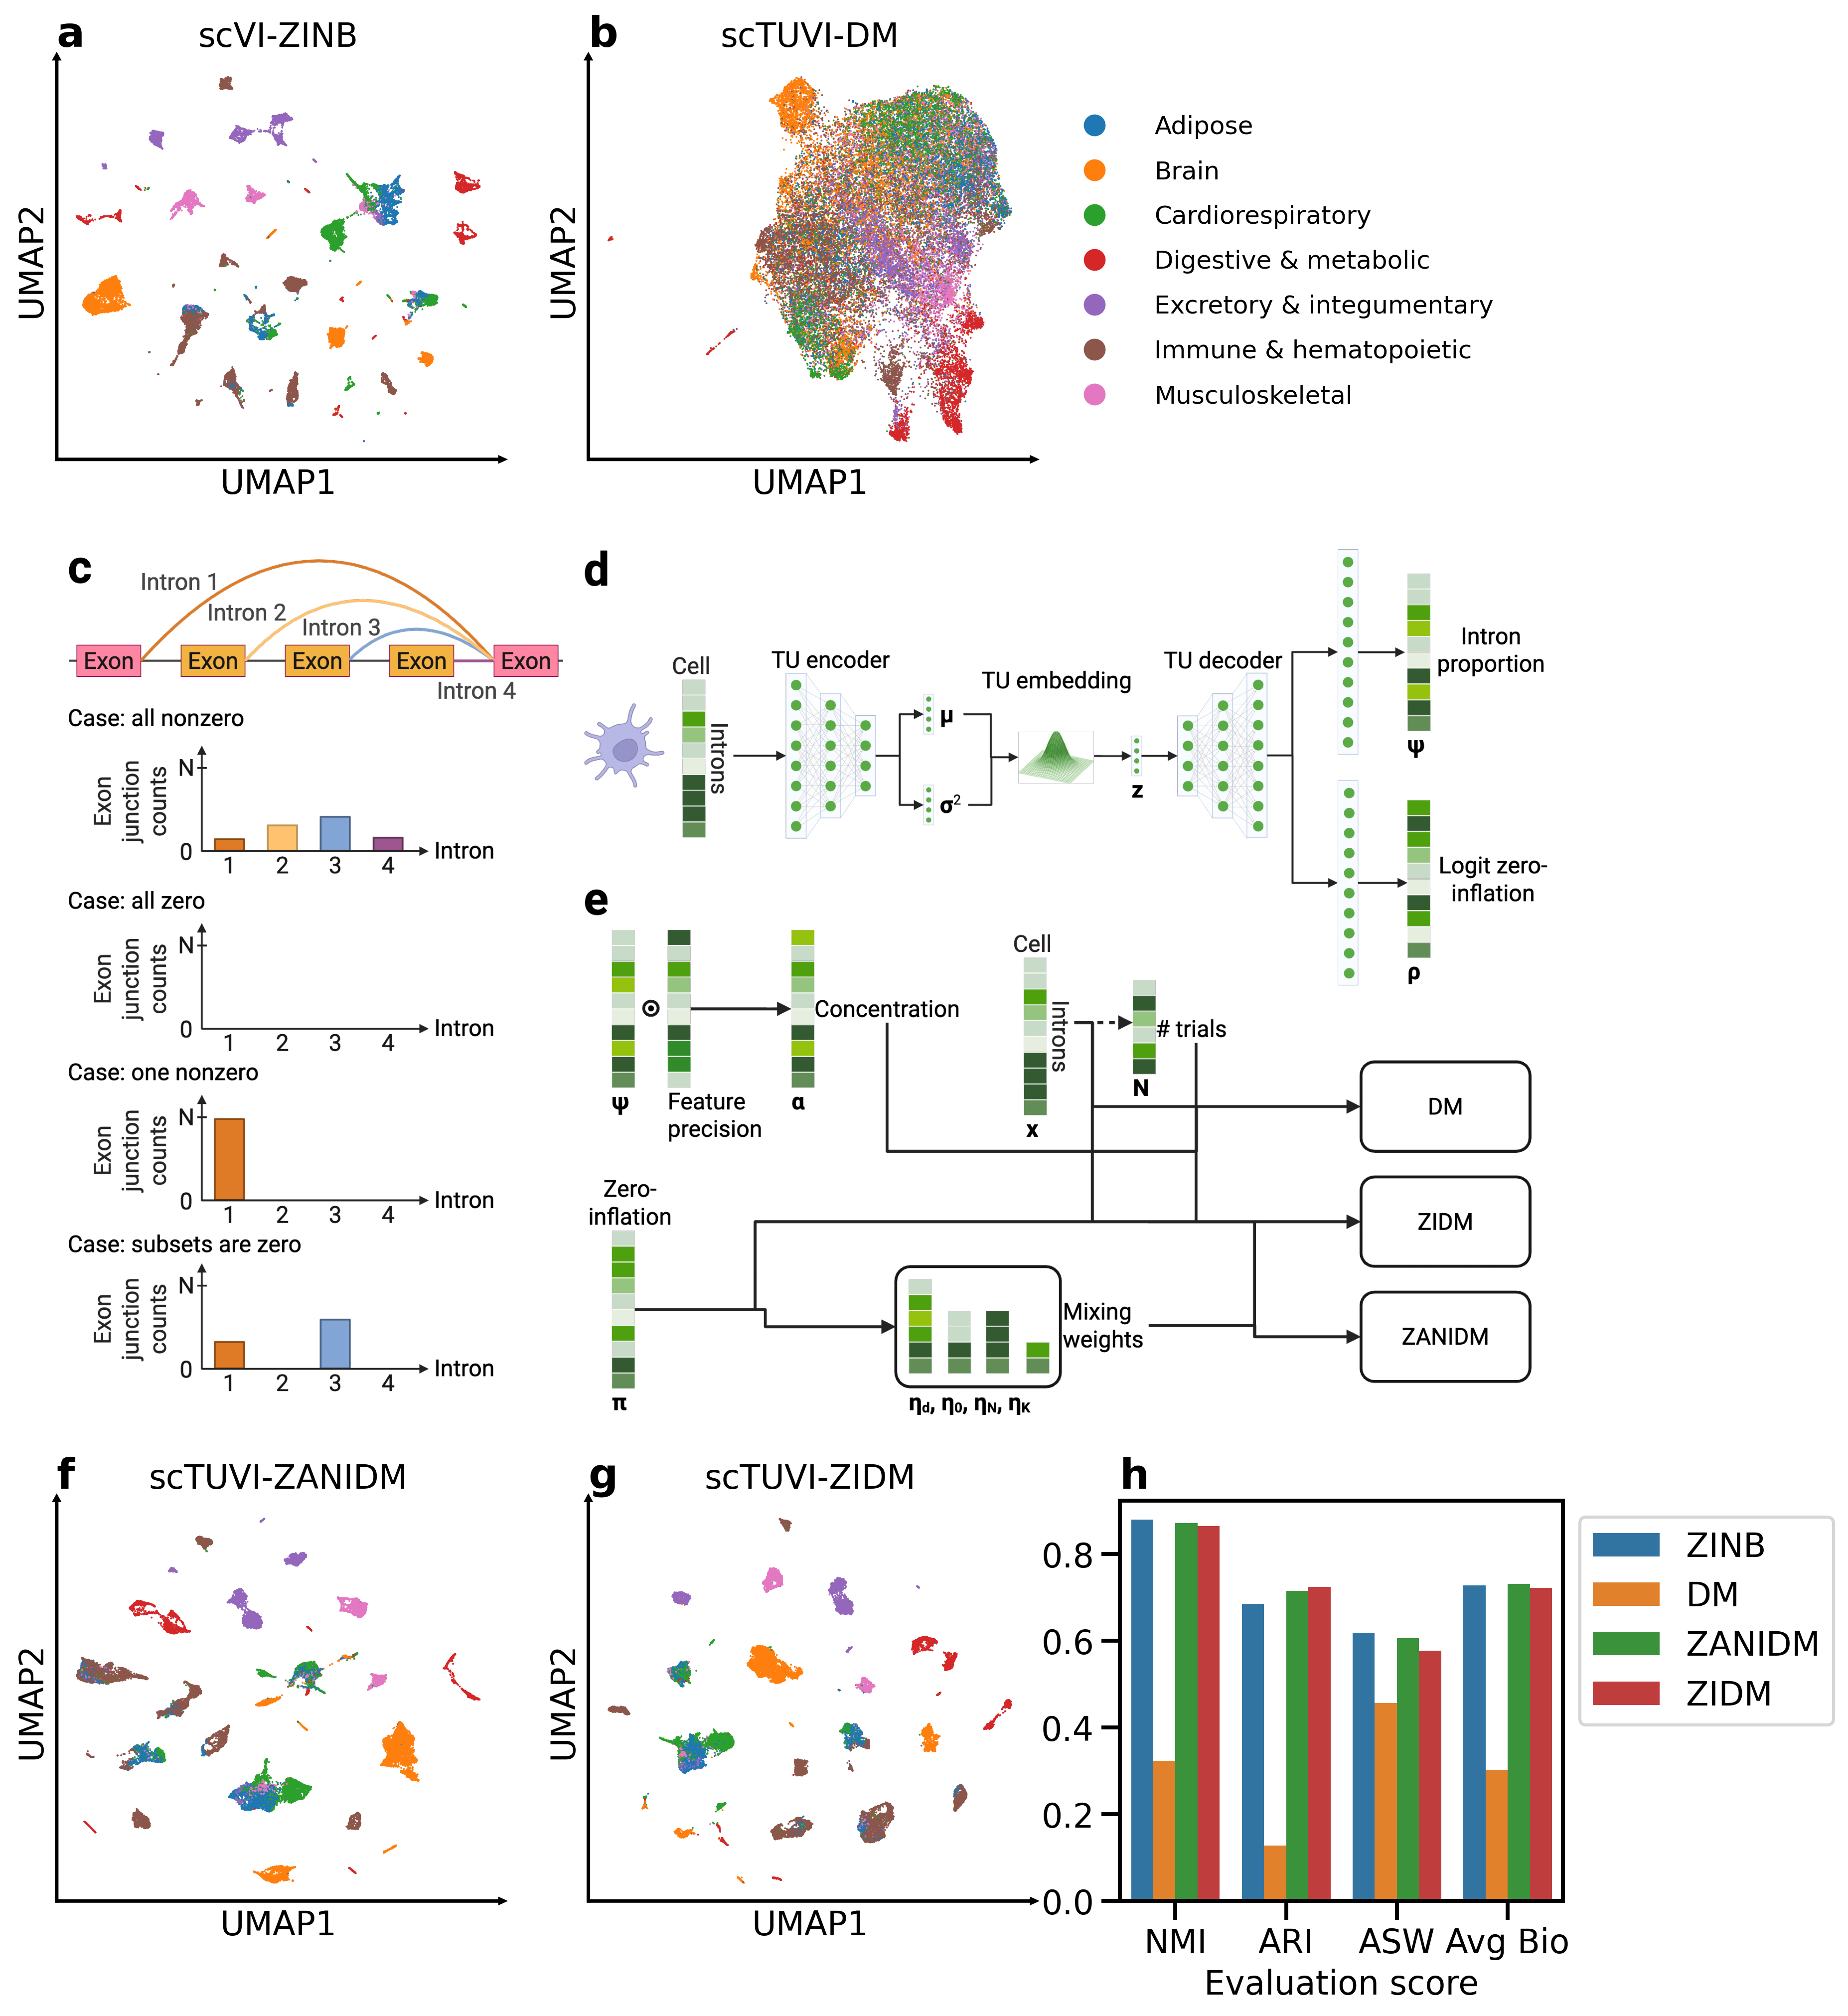

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import seaborn as sns
from crecerelle.plotting_utils import plot_customized_UMAP_coordinates, plot_scVI_scTUVI_cell_embedding_comparison

# Recalculate UMAPs if min_cells_per_tax_level > 0
if min_cells_per_tax_level > 0:
    # Calculate UMAP for chosen gene expression as well as for transcript usage embedding
    embedding_GE = likelihood_GE + "_latent_mean"
    adata_GE.obsm["X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_GE.obsm[embedding_GE])
    adata_TU.obsm["DM_X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_TU.obsm["DM_latent_mean"])
    adata_TU.obsm["ZANIDM_X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_TU.obsm["ZANIDM_latent_mean"])
    adata_TU.obsm["ZIDM_X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_TU.obsm["ZIDM_latent_mean"])

# @markdown **Save figure:** Tick box to save the figure.
save_fig = True # @param {type:"boolean"}
file_suffix = "svg" # @param ["pdf", "png", "svg"]

# @markdown **UMAP annotation:** Choose the annotation to be plotted on the UMAP (e.g. "organ system", "cell_ontology_class")
color_annotation = "organ_system" # @param

plot_scVI_scTUVI_cell_embedding_comparison(
        adata_objects=(adata_GE, adata_TU),
        evaluation_df=evaluation_df,
        color_annotation=color_annotation,
        likelihood_1=likelihood_GE,
        save_fig=save_fig,
        dataset_name=settings["dataset_name"],
        file_suffix=file_suffix
)



In [ ]:
# Optimal leiden resolution for scVI
import scib
resolutions = np.array([0.5, 0.6])
likelihood_key = "ZINB"

sc.pp.neighbors(adata_GE, use_rep=likelihood_key + "_latent_mean")

res_opt, nmi_opt = scib.me.cluster_optimal_resolution(
            adata_GE,
            cluster_key="cluster",
            resolutions=resolutions,
            label_key="cell_ontology_class"
        )

# Optimal resolution for scVI is 0.6 (40 cluster)

Cluster for cluster_0.5 with leiden


/usr/local/lib/python3.12/dist-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


resolution: 0.5, nmi: 0.884935455671651
Cluster for cluster_0.6 with leiden


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


resolution: 0.6, nmi: 0.885191243575281
optimised clustering against cell_ontology_class
optimal cluster resolution: 0.6
optimal score: 0.885191243575281


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
adata_GE.obs["cluster_0.6"].unique()

['3', '0', '1', '6', '9', ..., '23', '37', '33', '38', '39']
Length: 40
Categories (40, object): ['0', '1', '2', '3', ..., '36', '37', '38', '39']

In [ ]:
# Optimal leiden resolution for scTUVI-DM
import scib
resolutions = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
likelihood_key = "ZIDM" # "ZIDM", "ZANIDM"
sc.pp.neighbors(adata_TU, use_rep=likelihood_key + "_latent_mean")

res_opt, nmi_opt = scib.me.cluster_optimal_resolution(
            adata_TU,
            cluster_key="cluster",
            resolutions=resolutions,
            label_key="cell_ontology_class"
        )

# Optimal resolution for scTUVI-DM  is 1.4 (32 clusters)
# Optimal resolution for scTUVI-ZIDM is 0.9 (31 clusters)
# Optimal resolution for scTUVI-ZANIDM is 0.9 (38 cluster)

Cluster for cluster_0.5 with leiden


/usr/local/lib/python3.12/dist-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


resolution: 0.5, nmi: 0.8567424842482797
Cluster for cluster_0.6 with leiden


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


resolution: 0.6, nmi: 0.8575000122475677
Cluster for cluster_0.7 with leiden


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


resolution: 1.4, nmi: 0.8519056291991234
Cluster for cluster_1.5 with leiden


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/scib/metrics/clustering.py:96: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  cluster_function(adata, resolution=res, key_added=resolution_key, **kwargs)


resolution: 1.5, nmi: 0.8490907810312522
optimised clustering against cell_ontology_class
optimal cluster resolution: 0.9
optimal score: 0.8639101420185021


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
adata_TU.obs["cluster_0.9"].unique()

['3', '0', '2', '6', '9', ..., '24', '27', '28', '22', '29']
Length: 31
Categories (31, object): ['0', '1', '2', '3', ..., '27', '28', '29', '30']

# Splicing complements gene expression in cell annotation

To compare the gene expression and transcript usage cell embeddings inferred through scVI and scTUVI on cell annotation, it is necessary to run a differential gene expression and differential splicing analysis first. Then, the results are assembled.

## Differential gene expression analysis with scVI

Run a differential gene expression analysis to find the top differentially expressed genes (DEGs) to annotate the Leiden clusters of gene expression cell embeddings from scVI.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

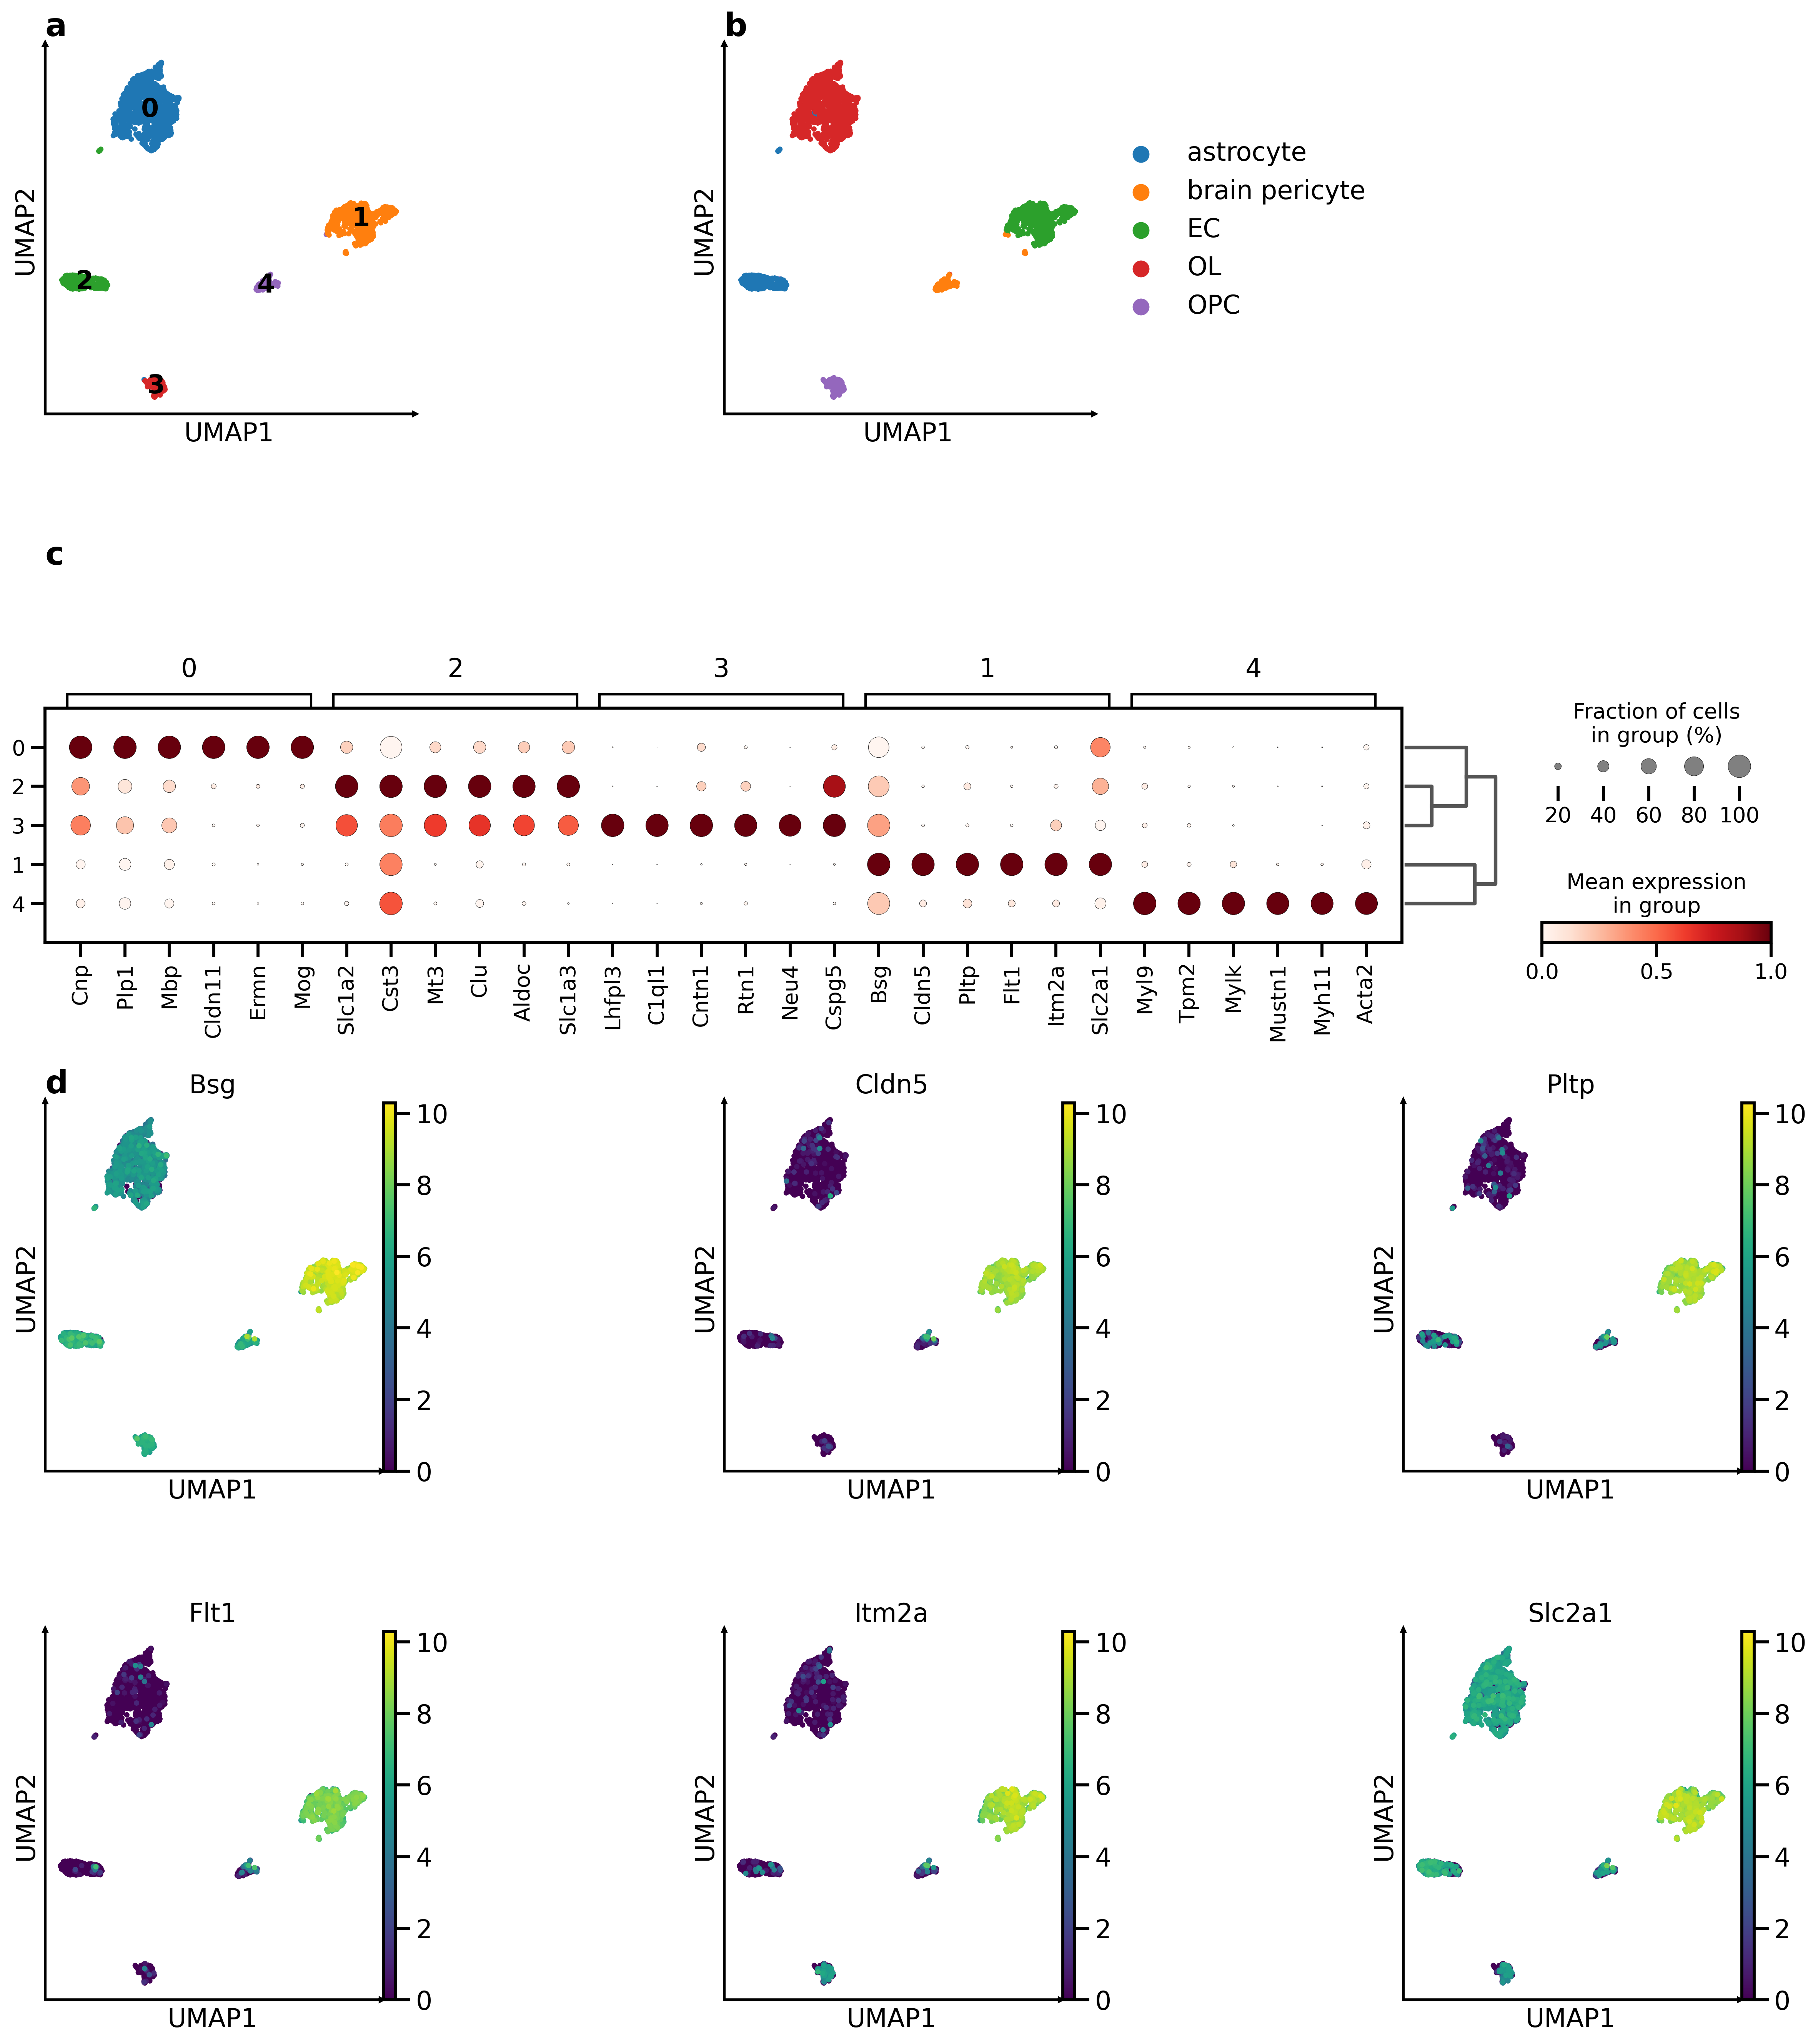

In [13]:
# @markdown **Cell taxonomy level:** Select the cell taxonomy level (e.g. tissue, cell classes) to analyse e.g. (tissue: "Brain_Non-Myeloid", "Heart")
tax_level = "Brain_Non-Myeloid" # @param ["Brain_Non-Myeloid", "Heart", "Liver"]
modality = "GE"

adata_GE_tissue = adata_GE[adata_GE.obs[settings["cell_type_groups_key"]] == tax_level].copy()

# @markdown **Filter cells on taxonomy level:** Filter out cell types with less than min_cells on taxonomy level

min_cells = 50 # @param {type:"integer"}

if min_cells > 0:
    cell_types, cell_counts = np.unique(adata_GE_tissue.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
    filtered_cell_types = cell_types[np.argwhere(cell_counts >= min_cells)].squeeze()

    # Filter adata_GE_train and adata_GE_val to filtered_cell_types
    adata_GE_tissue = adata_GE_tissue[adata_GE_tissue.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()


# @markdown **Model and observation model:**
model_key = "scVI" # @param ["scVI", "scGEVI"]
likelihood_key = "ZINB" # @param ["NB", "ZINB", "Gaussian"]
model_name = model_key + "_" + likelihood_key

sc.pp.neighbors(adata_GE_tissue, use_rep=likelihood_key + "_latent_mean", random_state=seed)

#adata_tissue.obsm["X_umap"] = adata_tissue.obsm[likelihood_key + "_X_umap"].copy()
adata_GE_tissue.obsm["X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_GE_tissue.obsm[likelihood_key + "_latent_mean"])

if likelihood_key == "NB":
    optimal_res = 0.21 # ZINB [0.21, 0.29, 0.33]  0.21 is best resolution
    leiden_res = "leiden_res_" + str(optimal_res)
elif likelihood_key == "ZINB":
    optimal_res = 0.1 # ZINB [0.21, 0.29, 0.33]  0.2 is best resolution for Brain, 0.1 for Heart
    leiden_res = "leiden_res_" + str(optimal_res)
elif likelihood_key == "Gaussian":
    optimal_res = 0.38 # Gaussian
    leiden_res = "leiden_res_" + str(optimal_res)
else:
    raise ValueError("Invalid likelihood key")

# Clustering using Leiden algorithm
#sc.tl.leiden(adata_GE_tissue, key_added=leiden_res, resolution=optimal_res, flavor="igraph", random_state=seed)
sc.tl.leiden(adata_GE_tissue, resolution=optimal_res, flavor="igraph", random_state=seed)

# Differential gene expression analysis
#grouby = leiden_res
grouby = "leiden"

# Obtain cluster-specific differentially expressed genes via the Wilcoxon test
sc.tl.rank_genes_groups(adata_GE_tissue, groupby=grouby, method="wilcoxon")

# @markdown **Save figure:**
save_fig = True # @param {type:"boolean"}
file_suffix = "pdf" # @param ["pdf", "png", "svg"]

import matplotlib.gridspec as gridspec
from crecerelle.plotting_utils import plot_customized_UMAP_coordinates

# @markdown **Cluster group:** Select the cluster group of the clustering algorithm to consider
cluster_group = "1" # @param ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]


# Plot results
from crecerelle.plotting_utils import plot_deg_analysis

plot_deg_analysis(
    adata=adata_GE_tissue,
    cluster_group=cluster_group,
    model_name=model_name,
    taxonomy_level=tax_level,
    save_fig=save_fig,
    dataset_name=settings["dataset_name"],
    cell_type_key=settings["cell_type_key"],
    file_suffix=file_suffix
)





In [14]:
# @markdown **Differential gene expression:** Select the number of top differentially expressed genes to be displayed
num_deg = 200 # @param {type:"integer"}
sc.get.rank_genes_groups_df(adata_GE_tissue, group=cluster_group).head(num_deg)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,names,scores,logfoldchanges,pvals,pvals_adj
0,Bsg,39.304348,6.784020,0.000000,0.000000
1,Cldn5,39.289383,15.182883,0.000000,0.000000
2,Pltp,39.275799,13.802685,0.000000,0.000000
3,Flt1,39.211189,14.028543,0.000000,0.000000
4,Itm2a,39.135403,13.567152,0.000000,0.000000
...,...,...,...,...,...
195,Stc1,2.373981,4.973916,0.017597,0.122488
196,Vtn,2.266779,0.938232,0.023404,0.161405
197,Sp1,2.063210,0.576605,0.039093,0.262955
198,Cngb1,1.969881,5.794264,0.048852,0.324958


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# @markdown **Threshold for pval_adj:** Select the threshold for significantly DEGs
sig_threshold = 0.05 # @param {type:"number"}

# Filter ranked gene groups to those smaller than sig_threshold
num_sig_degs = (sc.get.rank_genes_groups_df(adata_GE_tissue, group=cluster_group).head(num_deg)["pvals_adj"] < sig_threshold).to_numpy().sum()

print(f"Number of significantly DEGs in cluster {cluster_group}: {num_sig_degs}")

# @markdown Save adata_GE_tissue and rank_genes_groups_df as csv
save_adata_GE_tissue = True # @param {type:"boolean"}
if save_adata_GE_tissue:
    adata_GE_tissue.write(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_" + tax_level + "_vae_inference.h5ad")
    sig_rank_genes_groups_df = sc.get.rank_genes_groups_df(adata_GE_tissue, group=cluster_group).head(num_sig_degs)
    sig_rank_genes_groups_df.to_csv(path2data + "/deg_analysis_scVI_" + likelihood_key + "_" + tax_level + "_clustergroup_" + cluster_group + ".csv")


Number of significantly DEGs in cluster 1: 181


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
# @markdown Display the significant DEGs of the select cluster group
sig_deg_genes_group = sc.get.rank_genes_groups_df(adata_GE_tissue, group=cluster_group)["names"].to_numpy()[:num_sig_degs]
print(f"The significant DEGs of cluster group {cluster_group} are: \n {sig_deg_genes_group}")

The significant DEGs of cluster group 1 are: 
 ['Bsg' 'Cldn5' 'Pltp' 'Flt1' 'Itm2a' 'Slc2a1' 'Pglyrp1' 'Slco1a4' 'Ramp2'
 'Ptprb' 'Egfl7' 'Adgrf5' 'Adgrl4' 'Esam' 'Spock2' 'Wfdc1' 'Vwa1' 'Eng'
 'Hspb1' 'Jcad' 'Cxcl12' 'Abcg2' 'Emcn' 'Slco1c1' 'Fn1' 'Cavin2' 'Tek'
 'Pcp4l1' 'Epas1' 'Sema3c' 'Apold1' 'Ctla2a' 'Cdh5' 'Podxl' 'Prom1'
 'Slc22a8' 'Sox17' 'Lef1' 'Thbd' 'Icam2' 'Car4' 'Ly6c2' 'Tinagl1' 'Tie1'
 'Cd93' 'Tm4sf1' 'Plat' 'Foxq1' 'Kdr' 'Apcdd1' 'Sox18' 'Ushbp1' 'Slc40a1'
 'Gpr4' 'Tmem252' 'Mmrn2' 'Ceacam1' 'Gsta4' 'AU021092' 'Itga1' 'Robo4'
 'Rgcc' 'Tdrp' 'Nrp1' 'Cav1' 'Slc38a3' 'Hmgcs2' 'Hspa1a' 'Scarb1'
 'AW112010' 'Mfsd2a' 'Atf3' 'Aqp11' 'Rnf125' 'Tmem88' 'Lims2' 'Flt4'
 'Depp1' 'Acer2' 'Adcy4' 'Ccn1' 'Nrep' 'Serpinb9' 'Rasd1' 'Slc38a5'
 'Adamts1' 'Tcf7' 'Calcrl' 'Vwf' 'Gbp2' 'Stra6' 'Clec14a' 'Edn1' 'Edn3'
 'Ifit1' 'Dll4' 'Ndnf' 'Usp18' 'Rsad2' 'Stab1' 'Cst3' 'Alpl' 'Hbegf'
 'Cdkn1c' 'Tcim' 'Serpinb6b' 'Irf1' 'Gbp9' 'Ube2l6' 'Ackr3' 'Foxf1' 'Crem'
 'Cmpk2' 'Ifi44' 'Zap70' 'Iigp1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Differential splicing analysis with scTUVI

Run a differential splicing analysis to find the top differentially spliced genes (DSGs) to annotate the Leiden clusters of gene expression cell embeddings from scTUVI. We use the differential splicing test from scQuint.

In [9]:
# @markdown Install the scQuint package for the differential splicing test
!pip install -U git+https://github.com/songlab-cal/scquint.git

  Cloning https://github.com/songlab-cal/scquint.git to /tmp/pip-req-build-r39ddnhm
  Running command git clone --filter=blob:none --quiet https://github.com/songlab-cal/scquint.git /tmp/pip-req-build-r39ddnhm
  Resolved https://github.com/songlab-cal/scquint.git to commit cd255a134a9a082926d3be6c830c98af155d45bb
  Preparing metadata (setup.py) ... done


In [10]:
from scquint.data import add_gene_annotation, group_introns, filter_min_cells_per_feature, filter_min_cells_per_intron_group, calculate_PSI
from scquint.differential_splicing import run_differential_splicing, run_differential_splicing_for_each_group, find_marker_introns, mask_PSI
from scquint.dimensionality_reduction.pca import run_pca

# Make counts main layer again
if "counts" in adata_TU.layers:
    adata_TU.X = adata_TU.layers["counts"]
    adata_TU.layers.pop("counts")

# @markdown **Cell taxonomy level:** Select the cell taxonomy level (e.g. tissue, cell classes) to analyse e.g. (tissue: "Brain_Non-Myeloid", "Heart")
tax_level = "Brain_Non-Myeloid" # @param ["Heart", "Brain_Non-Myeloid", "Liver"]
adata_TU_tissue = adata_TU[adata_TU.obs[settings["cell_type_groups_key"]] == tax_level].copy()

# @markdown **Filter cells on taxonomy level:** Filter out cell types with less than min_cells on taxonomy level
min_cells = 50 # @param {type:"integer"}

if min_cells > 0:
    cell_types, cell_counts = np.unique(adata_TU_tissue.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
    filtered_cell_types = cell_types[np.argwhere(cell_counts >= min_cells)].squeeze()

    # Filter adata_TU_tissue to filtered_cell_types
    adata_TU_tissue = adata_TU_tissue[adata_TU_tissue.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()


# @markdown **Model and observation model:** Choose the deep generative model (model_key by default scTUVI) and the observation model (likelihood_key)
model_key = "scTUVI" # @param ["scTUVI"]
likelihood_key = "ZIDM" # @param ["DM", "ZIDM", "ZANIDM"]
model_name = model_key + "_" + likelihood_key


if likelihood_key == "DM":
    optimal_res = 0.3
    leiden_res = "leiden_res_" + str(optimal_res)
elif likelihood_key == "ZIDM":
    optimal_res = 0.2
    leiden_res = "leiden_res_" + str(optimal_res)
elif likelihood_key == "ZANIDM":
    optimal_res = 0.2
    leiden_res = "leiden_res_" + str(optimal_res)
else:
    raise ValueError("Invalid likelihood key")

# Compute UMAP on selected tissue
adata_TU_tissue.obsm[likelihood_key + "_X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_TU_tissue.obsm[likelihood_key + "_latent_mean"])

# Clustering using Leiden algorithm
sc.pp.neighbors(adata_TU_tissue, use_rep=likelihood_key + "_latent_mean", random_state=seed)
#sc.tl.leiden(adata_TU_tissue, key_added=leiden_res, resolution=optimal_res, flavor="igraph", random_state=seed)
sc.tl.leiden(adata_TU_tissue, resolution=optimal_res, flavor="igraph", random_state=seed)


# Filter minmum number of cells per feature and intron group
adata_TU_tissue = filter_min_cells_per_feature(adata_TU_tissue, 100)
adata_TU_tissue = filter_min_cells_per_intron_group(adata_TU_tissue, 100)

# Differential splicing analysis
#groups_test = adata_TU_tissue.obs[leiden_res].value_counts().index.tolist()
groups_test = adata_TU_tissue.obs["leiden"].value_counts().index.tolist()

diff_spl_intron_groups, diff_spl_introns = run_differential_splicing_for_each_group(
    adata_TU_tissue, "leiden", groups=groups_test, subset_to_groups=True,
    min_cells_per_intron_group=50, min_total_cells_per_intron=50,
    n_jobs=-1,  # -1 means use all cores
    # It will run much faster on a machine with multiple cores than in Colab
)





/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


filter_min_cells_per_feature
filter_singletons
filter_min_cells_per_intron_group
filter_singletons
3
sample sizes:  753 1901
(2654, 223)
filter_min_cells_per_feature
filter_singletons
(2654, 223)
filter_min_global_proportion
filter_singletons
(2654, 218)
filter_min_cells_per_intron_group
filter_singletons
filter_min_cells_per_intron_group


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


filter_singletons
(2654, 153)
Number of intron groups:  63
Number of introns:  153


 38%|███▊      | 24/63 [00:10<00:16,  2.32it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
 57%|█████▋    | 36/63 [00:10<00:07,  3.78it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datet

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
100%|██████████| 36/36 [00:00<00:00, 565.13it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(

4
sample sizes:  184 2470
(2654, 223)
filter_min_cells_per_feature
filter_singletons
(2654, 223)
filter_min_global_proportion
filter_singletons
(2654, 218)
filter_min_cells_per_intron_group
filter_singletons
filter_min_cells_per_intron_group
filter_singletons
(2654, 96)
Number of intron groups:  42
Number of introns:  96


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
100%|██████████| 42/42 [00:00<00:00, 710.34it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(

5
sample sizes:  146 2508
(2654, 223)
filter_min_cells_per_feature
filter_singletons
(2654, 223)
filter_min_global_proportion
filter_singletons
(2654, 218)
filter_min_cells_per_intron_group
filter_singletons
filter_min_cells_per_intron_group
filter_singletons
(2654, 43)
Number of intron groups:  20
Number of introns:  43


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
100%|██████████| 20/20 [00:00<00:00, 1197.65it/s]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace

In [11]:
# @markdown **Significance:** Determine the significantly spliced intron groups and select accordingly the significantly spliced introns
p_value_adj_thres = 0.05 # @param {type:"number"}
max_abs_delta_psi_thres = 0.05 # @param {type:"number"}

sig_diff_spl_intron_groups = diff_spl_intron_groups.query(f"p_value_adj < {p_value_adj_thres} and max_abs_delta_psi > {max_abs_delta_psi_thres}")
sig_spl_groups = list(sig_diff_spl_intron_groups["test_group"].unique())

#sig_diff_spl_introns = diff_spl_introns[diff_spl_introns["intron_group"].isin(sig_diff_spl_intron_groups["name"].to_list())]

sig_diff_spl_introns_df_list = []

for sig_group in sig_spl_groups:
    # Filter diff_spl_introns and sig_diff_spl_intron_groups to sig_group
    diff_spl_introns_sig_group = diff_spl_introns[diff_spl_introns["test_group"] == sig_group]
    sig_diff_spl_intron_groups_sig_group = sig_diff_spl_intron_groups[sig_diff_spl_intron_groups["test_group"] == sig_group]
    sig_diff_spl_introns_sig_group = diff_spl_introns_sig_group[diff_spl_introns_sig_group["intron_group"].isin(sig_diff_spl_intron_groups_sig_group["name"].to_list())]

    sig_diff_spl_introns_df_list.append(sig_diff_spl_introns_sig_group)

sig_diff_spl_introns = pd.concat(sig_diff_spl_introns_df_list, ignore_index=True)


# @markdown **Marker introns:** Select threshold for marker introns (> 0.0 means corresponding exon is included)
delta_psi_thres = 0.05 # @param {type:"number"}
marker_introns = sig_diff_spl_introns[sig_diff_spl_introns["delta_psi"] >= delta_psi_thres] # NEW

from crecerelle.utils import rank_intron_groups_groups
#rank_intron_groups_groups(adata_TU_tissue, sig_diff_spl_intron_groups, leiden_res)
rank_intron_groups_groups(adata_TU_tissue, sig_diff_spl_intron_groups, "leiden")

from crecerelle.utils import rank_introns_groups
#rank_introns_groups(adata_TU_tissue, sig_diff_spl_introns, leiden_res, "delta_psi", groups_test)
#rank_introns_groups(adata_TU_tissue, sig_diff_spl_introns, "leiden", "delta_psi", groups_test)
rank_introns_groups(adata_TU_tissue, marker_introns, "leiden", "delta_psi", sig_spl_groups) # NEW

/usr/local/lib/python3.12/dist-packages/crecerelle/utils.py:598: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["rank_intron_groups_groups"] = rank_introns_groups_dict
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
marker_introns

,chromosome,start,end,strand,annotated,gene_id_start,gene_id_end,n_genes,gene_id,gene_name,...,intron_group_size,n_genes_per_intron_group,psi_a,psi_b,delta_psi,lfc_psi,abs_delta_psi,abs_lfc_psi,test_group,name
0,chr15,54850128,54851347,-,True,ENSMUSG00000022425,ENSMUSG00000022425,1,ENSMUSG00000022425,Enpp2,...,2,1,0.418457,0.281600,0.136857,0.571434,0.136857,0.571434,3,Enpp2_chr15:54850128-54851347
3,chr16,31311165,31314551,-,True,ENSMUSG00000022548,ENSMUSG00000022548,1,ENSMUSG00000022548,Apod,...,2,1,0.187106,0.135791,0.051315,0.462465,0.051315,0.462465,3,Apod_chr16:31311165-31314551
8,chr5,125277866,125283898,-,True,ENSMUSG00000037936,ENSMUSG00000037936,1,ENSMUSG00000037936,Scarb1,...,2,1,0.845818,0.255565,0.590253,1.726658,0.590253,1.726658,3,Scarb1_chr5:125277866-125283898
12,chr11,87583615,87583920,+,True,ENSMUSG00000020486,ENSMUSG00000020486,1,ENSMUSG00000020486,Septin4,...,6,1,0.724991,0.518709,0.206282,0.483038,0.206282,0.483038,3,Septin4_chr11:87583615-87583920
16,chr12,16656871,16658364,+,True,ENSMUSG00000020591,ENSMUSG00000020591,1,ENSMUSG00000020591,Ntsr2,...,4,1,0.690699,0.540473,0.150226,0.353835,0.150226,0.353835,3,Ntsr2_chr12:16656871-16658364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,chr18,31955409,31956257,+,True,ENSMUSG00000024395,ENSMUSG00000024395,1,ENSMUSG00000024395,Lims2,...,3,1,1.000000,0.930679,0.069321,0.103644,0.069321,0.103644,5,Lims2_chr18:31955409-31956257
210,chr2,35266904,35283904,+,True,ENSMUSG00000026879,ENSMUSG00000026879,1,ENSMUSG00000026879,Gsn,...,4,1,0.926746,0.067981,0.858765,3.768975,0.858765,3.768975,5,Gsn_chr2:35266904-35283904
213,chr6,88724572,88725700,+,True,ENSMUSG00000033174,ENSMUSG00000033174,1,ENSMUSG00000033174,Mgll,...,2,1,0.922825,0.716210,0.206615,0.365675,0.206615,0.365675,5,Mgll_chr6:88724572-88725700
216,chr9,44140694,44140844,+,True,ENSMUSG00000032135,ENSMUSG00000032135,1,ENSMUSG00000032135,Mcam,...,2,1,0.996310,0.621129,0.375181,0.681702,0.375181,0.681702,5,Mcam_chr9:44140694-44140844


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
adata_TU_tissue.uns["rank_intron_groups_groups"]

{'params': {'groupby': 'leiden', 'method': 'dm_glm_likelihood_ratio'},
 'names': rec.array([('Lims2_chr18_31941739_+', 'Septin4_chr11_87583920_+', 'Limch1_chr5_66969075_+', 'Gsn_chr2_35283904_+', 'Plp1_chrX_136833267_+', 'Gsn_chr2_35283904_+'),
            ('Lims2_chr18_31954435_+', 'Apod_chr16_31311165_-', 'Gpm6a_chr8_55037327_+', 'Septin4_chr11_87583920_+', 'Enpp2_chr15_54850128_-', 'Septin4_chr11_87583920_+'),
            ('Gsn_chr2_35283904_+', 'Scarb1_chr5_125277866_-', 'Clu_chr14_65971731_+', 'Enpp2_chr15_54850128_-', 'Lims2_chr18_31956257_+', 'Mcam_chr9_44140844_+'),
            ('Enpp2_chr15_54850128_-', 'Enpp2_chr15_54850128_-', 'Mbp_chr18_82572824_+', 'Scarb1_chr5_125277866_-', 'Gpm6a_chr8_55037327_+', 'Mcam_chr9_44141783_+'),
            ('Lims2_chr18_31956257_+', 'Lims2_chr18_31941739_+', 'Rtn1_chr12_72223540_-', 'Apod_chr16_31311165_-', 'Gsn_chr2_35283904_+', 'Nrep_chr18_33463420_-'),
            ('Scarb1_chr5_125277866_-', 'Lims2_chr18_31954435_+', 'Gsn_chr2_35283904_+', 

In [14]:
adata_TU_tissue.uns["rank_introns_groups"]

{'params': {'groupby': 'leiden', 'method': 'dm_glm_likelihood_ratio'},
 'names': rec.array([('Scarb1_chr5:125277866-125283898', 'Scarb1_chr5:125277866-125281104', 'Scarb1_chr5:125277866-125283898', 'Rtn1_chr12:72223540-72303656', 'Gsn_chr2:35266904-35283904', 'Gsn_chr2:35266904-35283904'),
            ('Septin4_chr11:87583615-87583920', 'Septin4_chr11:87578538-87583920', 'Lims2_chr18:31931551-31941739', 'Limch1_chr5:66968734-66969075', 'Gpm6a_chr8:54955316-55037327', 'Septin4_chr11:87578538-87583920'),
            ('Mcam_chr9:44140504-44140844', 'Nrep_chr18:33463420-33463852', 'Mgll_chr6:88725179-88725700', 'Gpm6a_chr8:54779651-55037327', 'Lims2_chr18:31955215-31956257', 'Nrep_chr18:33463420-33463599'),
            ('Zcchc18_chrX:136993353-136993706', 'Crem_chr18:3273579-3280948', 'Gpm6a_chr8:54779651-55037327', 'Gsn_chr2:35266904-35283904', 'Plp1_chrX:136832110-136833267', 'Mcam_chr9:44140694-44140844'),
            ('Ntsr2_chr12:16656871-16658364', 'Enpp2_chr15:54919699-54952547', 'L

/usr/local/lib/python3.12/dist-packages/scquint/data.py:212: RuntimeWarning: invalid value encountered in divide
  return X / intron_group_sums[:,groups]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/crecerelle/plotting_utils.py:1794: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layo

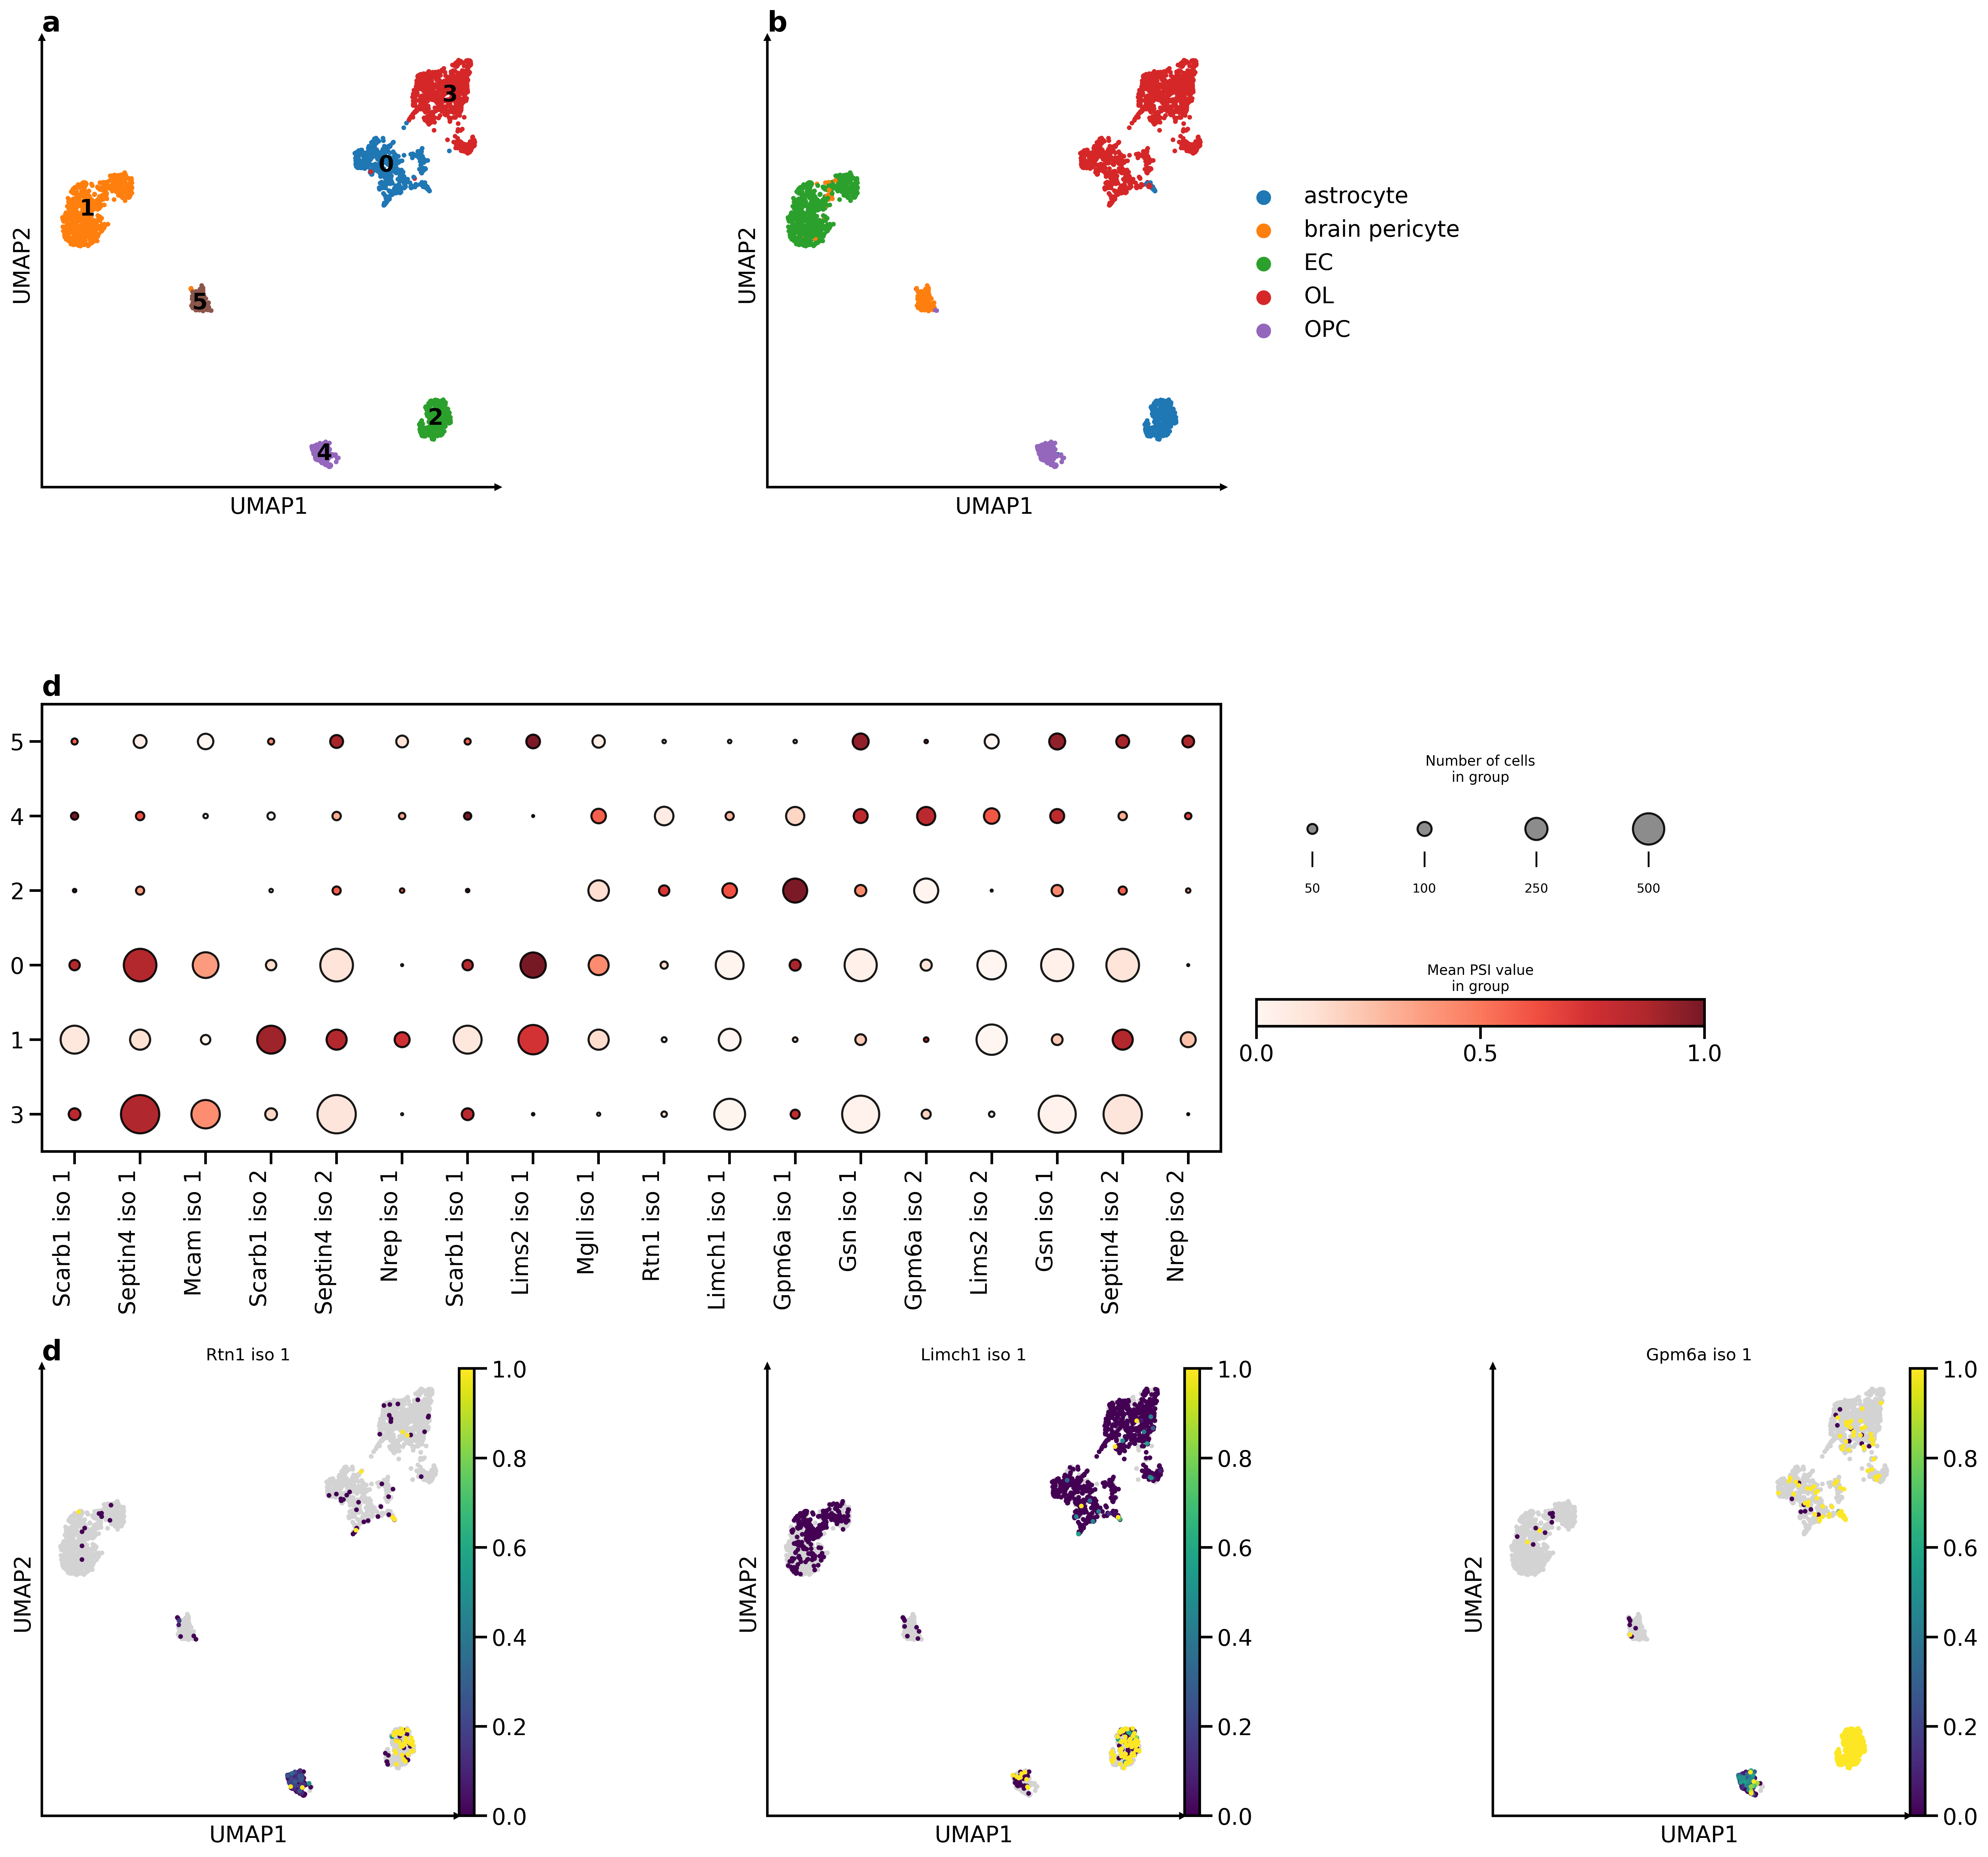

In [19]:
from crecerelle.plotting_utils import plot_customized_UMAP_coordinates
from matplotlib import gridspec

# Calculate raw PSI scores
adata_TU_tissue.layers["PSI_raw"] = calculate_PSI(adata_TU_tissue)

# @markdown **Save figure:** Select if figure is saved
save_fig = True # @param {type:"boolean"}

# @markdown **Clustering group:** Select a clustering group for analysis
cluster_group = "2" # @param ["0", "1", "2", "3", "4", "5", "6", "7"]

# Set X_umap according to likelihood_key
adata_TU_tissue.obsm["X_umap"] = adata_TU_tissue.obsm[likelihood_key + "_X_umap"].copy()

rename_isoforms = True

# Plot DSG analysis results
from crecerelle.plotting_utils import plot_dsg_analysis
plot_dsg_analysis(
    adata=adata_TU_tissue,
    cluster_group=cluster_group,
    cluster_groups=groups_test,
    model_name=model_name,
    taxonomy_level=tax_level,
    rename_isoforms=rename_isoforms,
    save_fig=save_fig,
    dataset_name=settings["dataset_name"],
    cell_type_key=settings["cell_type_key"]
)

In [20]:
# Save DSGs of group_id as .csv
from crecerelle.utils import rank_introns_groups_df

# @markdown Save adata_TU_tissue and rank_introns_groups_df as csv
save_adata_TU_tissue = True # @param {type:"boolean"}
if save_adata_TU_tissue:
    adata_TU_tissue.write(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_" + tax_level + "_vae_inference.h5ad")

    rank_introns_groups_df = rank_introns_groups_df(adata_TU_tissue, cluster_group)
    rank_introns_groups_df.to_csv(path2data + "dsg_analysis_scTUVI_" + likelihood_key + "_" + tax_level + "_clustergroup_" + cluster_group + ".csv")

    print("AnnData file and csv file have been saved")


AnnData file and csv file have been saved


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/matplotlib/backends/backend_pdf.py:1761: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Figure saved to: ./figures/tabulaMuris/dsg_analysis_umaps_scTUVI_ZIDM_Brain_Non-Myeloid.pdf


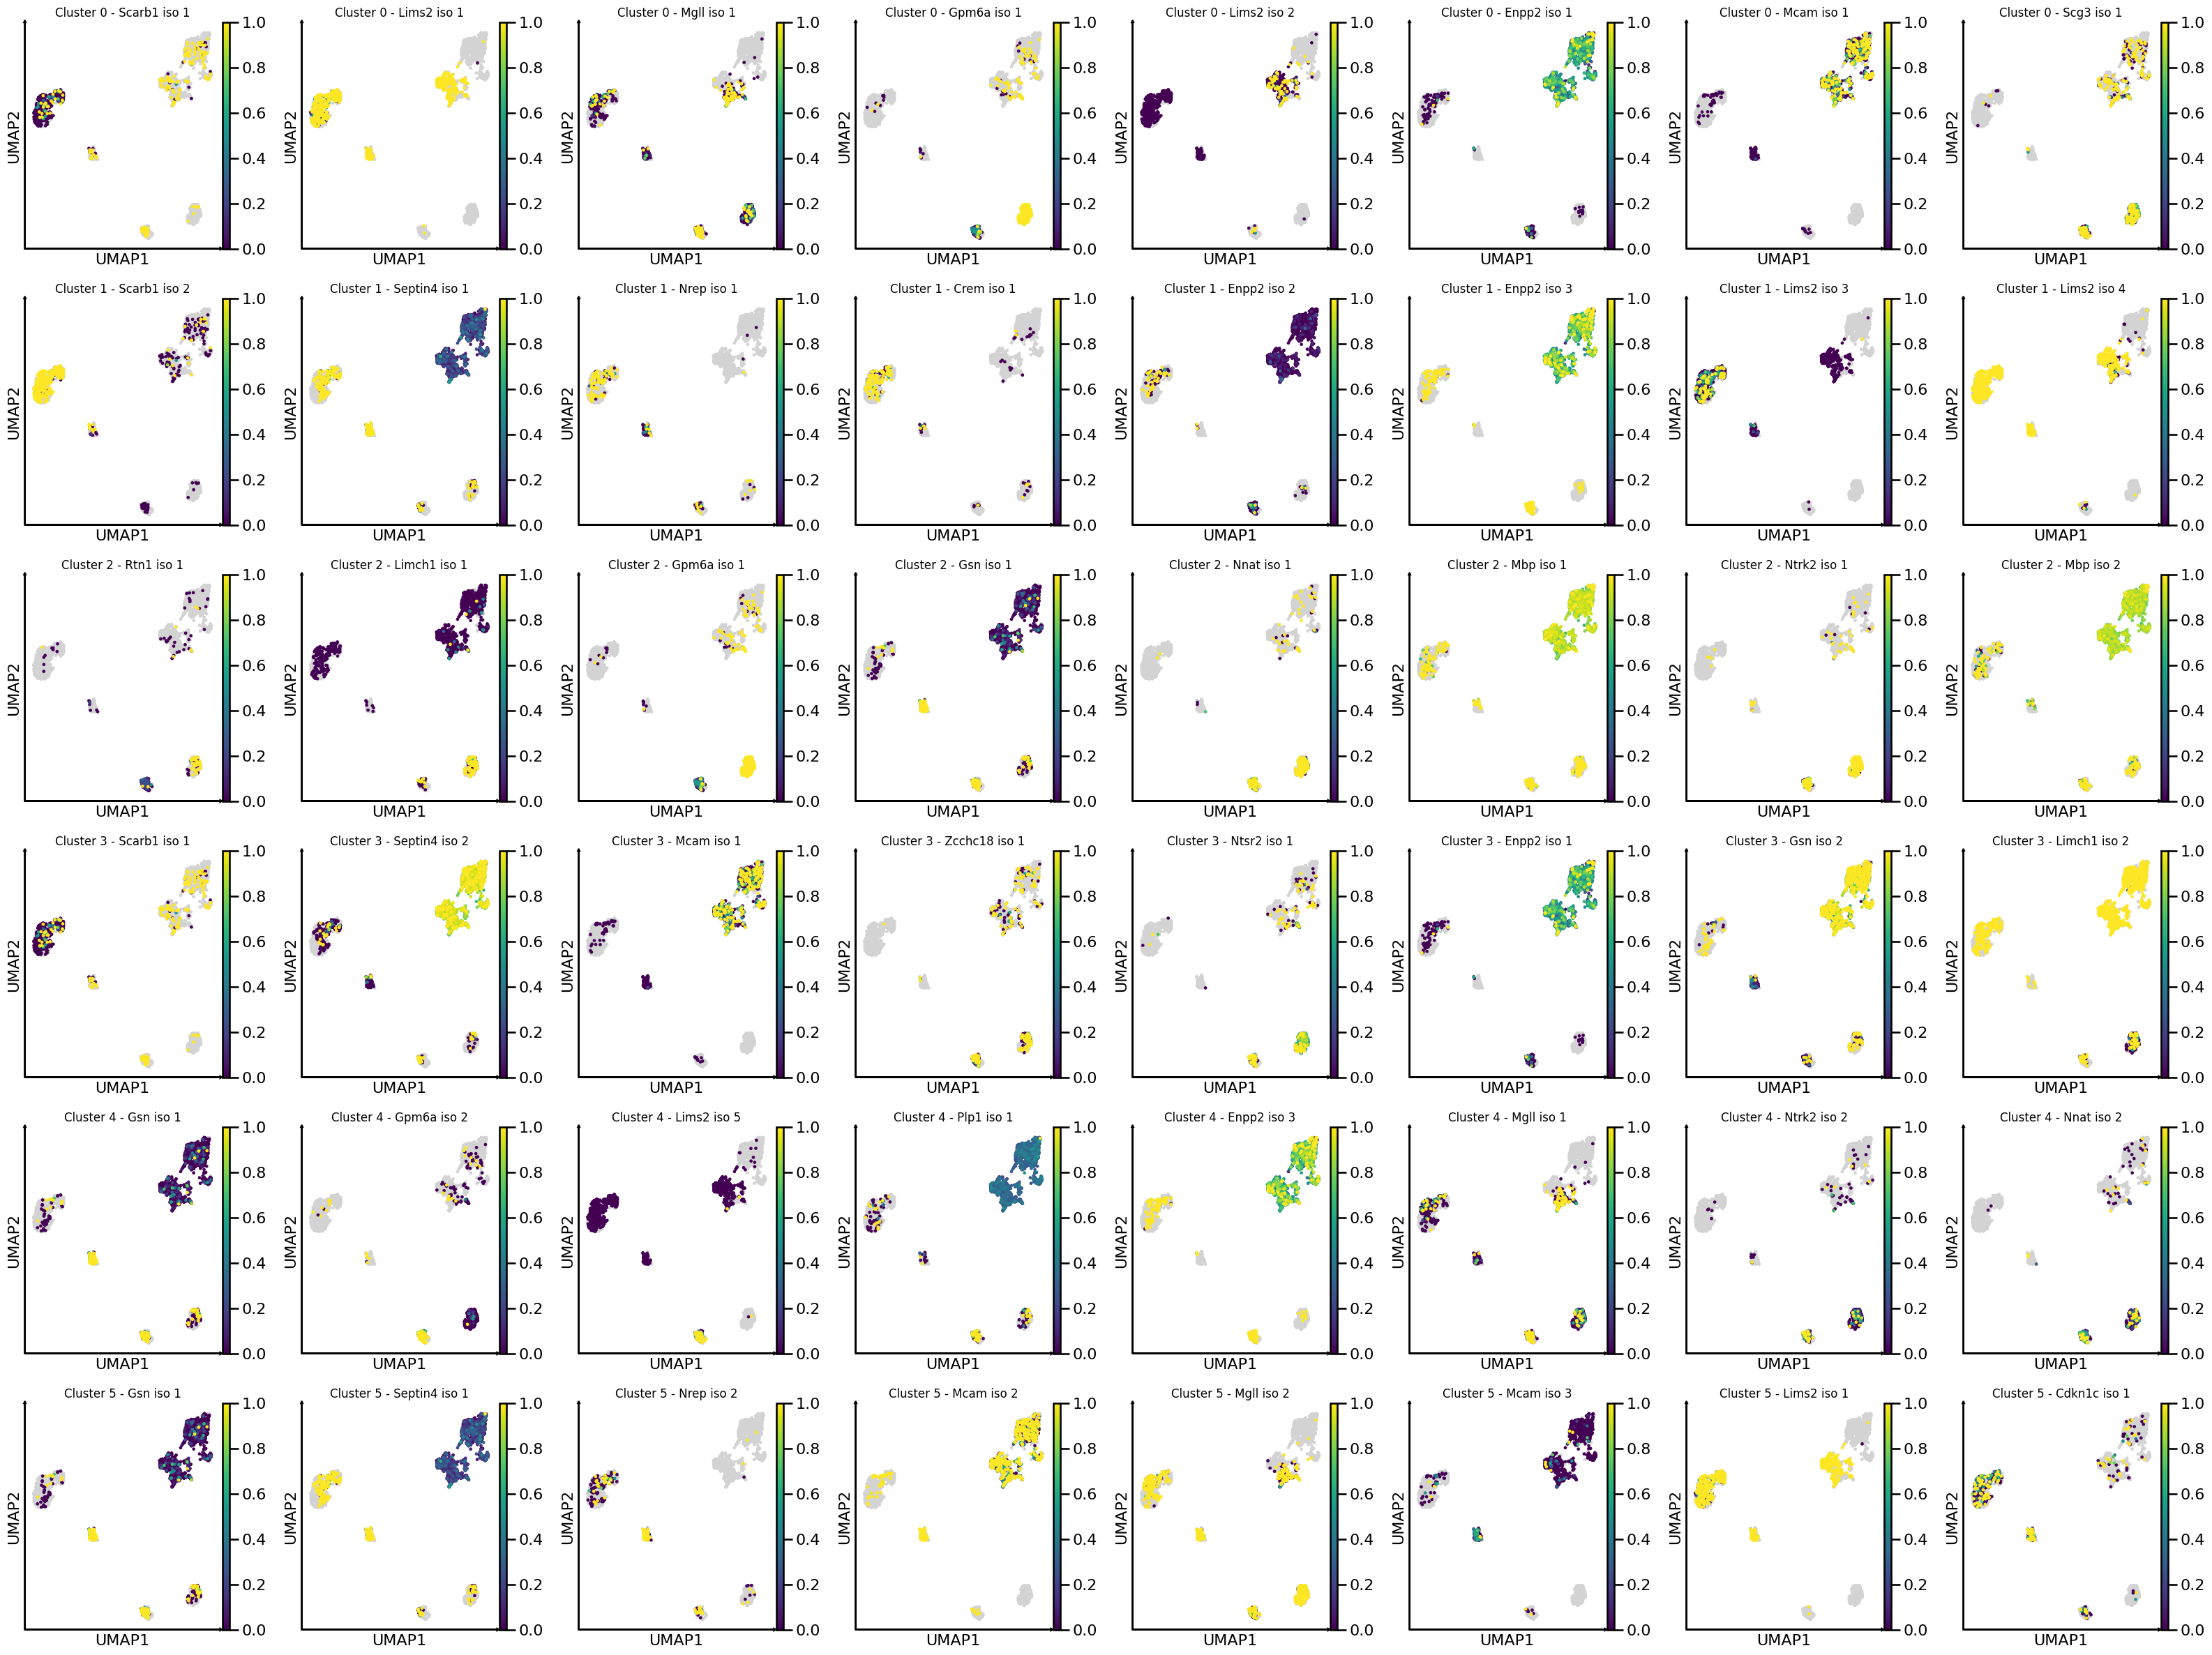

In [ ]:
# @markdown **PSI score of top three DSG isoforms:** The PSI score of the top 3 DSG isoforms is plotted for the specified cluster groups is plotted on the UMAP

# Plot top 3 DSG isoforms per cluster for supplmentary material (might need some adjustments)
from crecerelle.plotting_utils import plot_differential_analysis_on_umap, rename_isoform_helper, dsg_dotplot_helper

# @markdown **Cluster groups:** Specify the Leiden cluster groups for which the top three DEGs are plotted
cluster_groups = ["0", "1", "2", "3", "4", "5"] # @param

# @markdown **Number of isoform marker:** Specify the the number of isoform markers to be displayed per cluster group
num_isoform_markers = 8 # @param {type:"integer"}


# Rename isoforms
_, _, intron_names_dsg_plot = dsg_dotplot_helper(adata_TU_tissue, cluster_groups, num_isoform_markers)
renamed_isoforms = rename_isoform_helper(intron_names_dsg_plot)

# @markdown **Save figure:** Tick the box to save the figure
save_fig = True # @param {type:"boolean"}

plot_differential_analysis_on_umap(
        adata_TU_tissue,
        cluster_groups,
        tax_level,
        model_key + "_" +likelihood_key,
        "TU",
        renamed_isoforms = renamed_isoforms,
        save_fig = save_fig,
        dataset_name=settings["dataset_name"],
        num_entities_per_group=num_isoform_markers
)

### Archive

In [ ]:
intron_names_group = adata_TU_tissue.uns["rank_introns_groups"]["names"]["3"][:num_intron_group_markers]

In [ ]:
intron_names_group

array(['Dcn_chr10:97479790-97483338', 'Mfge8_chr7:79143051-79145246',
       'Emcn_chr3:137391707-137416720'], dtype=object)

In [ ]:
from crecerelle.utils import rank_introns_groups_df

sorting = "delta_psi" # "logfoldchanges", "delta_psi", "intron_groups"

rank_introns_groups_df = rank_introns_groups_df(adata_TU_tissue, group_id)

if sorting == "logfoldchanges":
    rank_introns_groups_df = rank_introns_groups_df.sort_values(by='logfoldchanges', ascending=False)
elif sorting == "delta_psi":
    rank_introns_groups_df = rank_introns_groups_df.sort_values(by='delta_psi', ascending=False)
elif sorting == "intron_groups":
    pass
else:
    raise ValueError("Invalid sorting")

rank_introns_groups_df

,names,logfoldchanges,delta_psi
0,Dcn_chr10:97479790-97483338,0.598768,0.337074
1,Mfge8_chr7:79143051-79145246,0.150948,0.096958
2,Emcn_chr3:137391707-137416720,1.090004,0.078714
3,Cdkn1c_chr7:143459251-143459758,0.262020,0.076842
4,Nrp1_chr8:128480969-128487896,0.445427,0.055798
5,0,0.000000,0.000000
6,0,0.000000,0.000000
7,0,0.000000,0.000000
8,0,0.000000,0.000000
9,0,0.000000,0.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
marker_introns = rank_introns_groups_df["names"].head(6).to_list()

TypeError: 'numpy.int64' object is not iterable

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


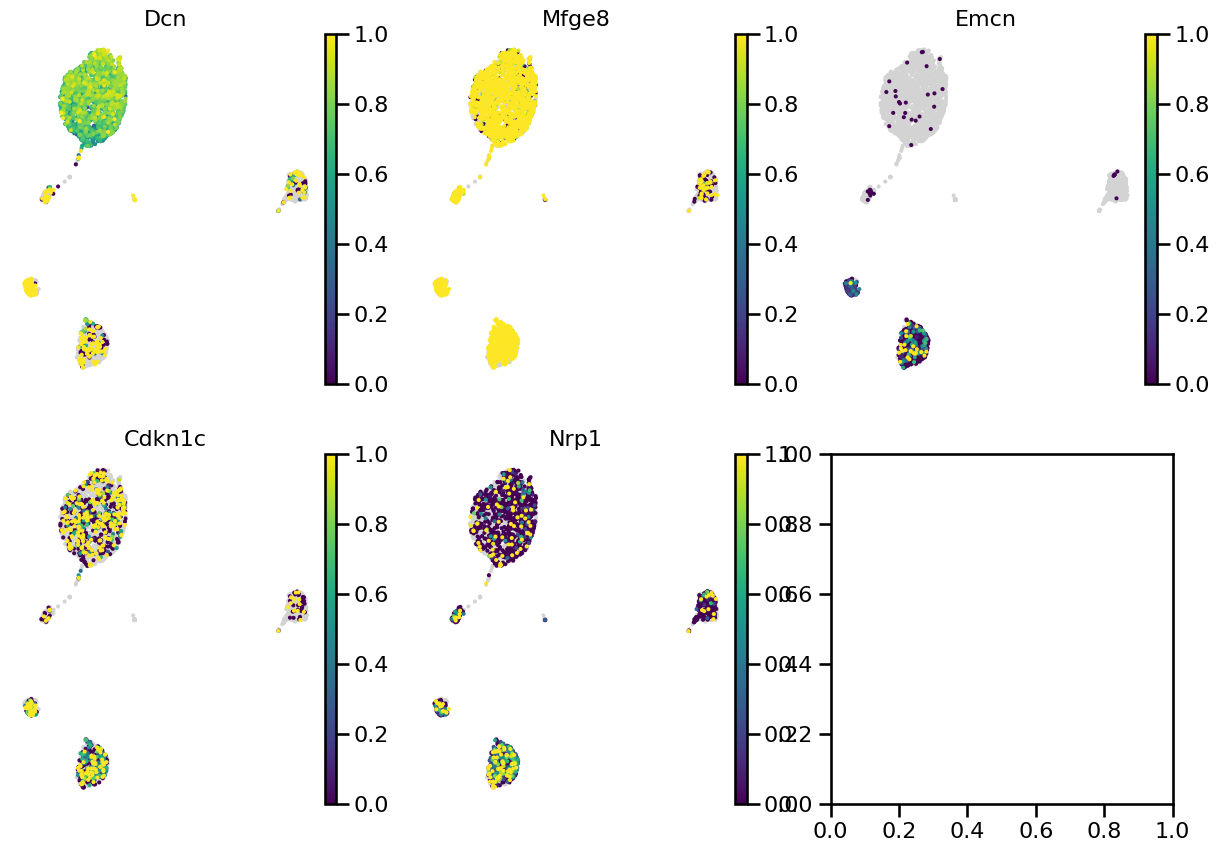

In [ ]:


import math
# 1. Configuration
n_cols = 3
n_rows = math.ceil(len(marker_introns) / n_cols)

# 2. Initialize the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axes = axes.flatten()  # Flatten to iterate easily even if it's a 2D array

adata_TU_tissue.obsm["X_umap"] = adata_TU_tissue.obsm[likelihood_key + "_X_umap"].copy()


# 3. Loop through introns and axes
for i, marker_intron in enumerate(marker_introns):
    sc.pl.umap(
        adata_TU_tissue,
        color=marker_intron,
        layer="PSI_raw",
        frameon=False,
        show=False,
        ax=axes[i]  # Direct the plot to the specific subplot
    )
    axes[i].set_title(marker_intron.split('_')[0]) # Optional: Clean up title

del adata_TU_tissue.obsm["X_umap"]

# 4. Remove empty subplots if len(marker_introns) is not a multiple of n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

fig.savefig("./figures/tabulaMuris/dsg_analysis_heart_sort_" + sorting +  "_clustergroup_" + group_id + "_marker_introns.pdf", dpi=300)
plt.show()

In [ ]:
rank_introns_groups_df = rank_introns_groups_df.sort_values(by='logfoldchanges', ascending=False)
rank_introns_groups_df

,names,logfoldchanges,delta_psi
4,Fmo1_chr1:162859563-162859800,8.661398,0.961648
0,Fbln2_chr6:91259771-91263338,3.594142,0.891002
7,AW112010_chr19:11048393-11055779,2.765526,0.153994
2,Dcn_chr10:97482548-97483338,2.753611,0.292339
1,Lims2_chr18:31931551-31941739,2.223565,0.776375
13,Fbln5_chr12:101814597-101818232,1.498353,0.065511
3,Gsn_chr2:35282602-35283904,0.949690,0.455128
6,Pi16_chr17:29327634-29327837,0.936770,0.300281
9,Nrep_chr18:33463420-33463599,0.860870,0.310717
11,Mfge8_chr7:79143051-79143277,0.771835,0.055772


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,names,logfoldchanges,delta_psi
0,Fbln2_chr6:91259771-91263338,3.594142,0.891002
1,Lims2_chr18:31931551-31941739,2.223565,0.776375
2,Dcn_chr10:97482548-97483338,2.753611,0.292339
3,Gsn_chr2:35282602-35283904,0.949690,0.455128
4,Fmo1_chr1:162859563-162859800,8.661398,0.961648
5,Nrp1_chr8:128480990-128487896,0.242369,0.141956
6,Pi16_chr17:29327634-29327837,0.936770,0.300281
7,AW112010_chr19:11048393-11055779,2.765526,0.153994
8,Fmo2_chr1:162898312-162898671,0.671958,0.333760
9,Nrep_chr18:33463420-33463599,0.860870,0.310717


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
sig_dsg_list_group = rank_introns_groups_df["names"].to_list()

# Keep only gene name from each item (for each str in sig_dsg_list_group only keep characters until "_")
sig_dsg_list_group = [item.split("_")[0] for item in sig_dsg_list_group]

sig_dsg_genes, indices = np.unique(np.array(sig_dsg_list_group), return_index=True)
sig_dsg_genes_group = sig_dsg_genes[np.argsort(indices)]
num_sig_dsg_genes = len(sig_dsg_genes_group)

AttributeError: 'numpy.int64' object has no attribute 'split'

In [ ]:
sig_deg_genes_group

array(['Dcn', 'Gsn', 'Fbln1', 'Serping1', 'Ccdc80', 'Col1a1', 'Gpx3',
       'Col3a1', 'Col1a2', 'Dpep1', 'Mfap5', 'Ogn', 'Gpm6b', 'Gstm1',
       'Fbln5'], dtype=object)

In [ ]:
sc.pl.umap(adata_TU_tissue, color=intron_names[1], layer="PSI_raw")

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


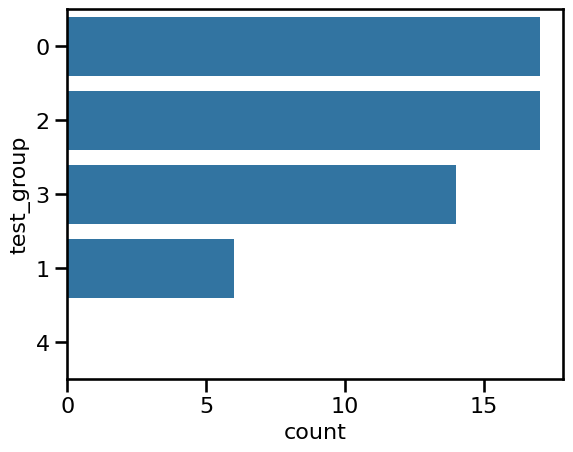

In [ ]:
import seaborn as sns
# Number of significant events per cell type
sns.countplot(sig_diff_spl_intron_groups, y="test_group", color="C0", order=groups_test);

## Cell annotation based on gene expression or splicing using Crecerelle

Comparing gene expression-based with transript-usage-based cell annotation using *Crecerelle* emphasises how both transcriptomic facets complement each other.

In [9]:
# @markdown **Random seed:** select the random seed (choose 0 for reproducing the results of the paper)
seed = 1 # @param {type:"integer"} 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
settings["seed"] = seed
torch.manual_seed(seed)
np.random.seed(seed)

# @markdown **Taxonomy level:** Choose the processed taxonomy level (e.g. tissue "Brain_Non-Myeloid", tissue "Heart") for the cell annotation analysis
tax_level = "Brain_Non-Myeloid" # @param ['Aorta', 'BAT', 'Bladder', 'Brain_Myeloid', 'Brain_Non-Myeloid', 'Diaphragm', 'GAT', 'Heart', 'Kidney', 'Large_Intestine', 'Limb_Muscle', 'Liver', 'Lung', 'MAT', 'Mammary_Gland', 'Marrow', 'Pancreas', 'SCAT', 'Skin', 'Spleen', 'Thymus', 'Tongue', 'Trachea']

# Filter adata objects to tissue
#adata_GE_tissue = adata_GE[adata_GE.obs["tissue"] == tissue].copy()
#adata_TU_tissue = adata_TU[adata_TU.obs["tissue"] == tissue].copy()
adata_GE_tissue = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_" + tax_level + "_vae_inference.h5ad")
adata_TU_tissue = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_" + tax_level + "_vae_inference.h5ad")

# @markdown **Baseline gene expression observation model:** Select the likelihood for scVI that shall be used as reference for the comparison with the observation models (DM, ZANIDM, ZIDM) of scTUVI
likelihood_GE = "ZINB" # @param ["NB", "ZINB", "Gaussian"]

# Calculate UMAP on tissue level for gene expression
adata_GE_tissue.obsm[likelihood_GE + "_X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_GE_tissue.obsm[likelihood_GE + "_latent_mean"])

# Calculate UMAPs on tissue level for transcript usage
likelihood_TU = "ZIDM" # @param ["DM", "ZIDM", "ZANIDM"]

adata_TU_tissue.obsm[likelihood_TU + "_X_umap"] = UMAP(n_components=2, random_state=seed).fit_transform(adata_TU_tissue.obsm[likelihood_TU + "_latent_mean"])

# Calculate raw PSI scores
#adata_TU_tissue.layers["PSI_raw"] = calculate_PSI(adata_TU_tissue)

# @markdown **Cluster group:** Choose the cluster group id for GE and TU
group_id_GE = "1" # @param ["0", "1", "2", "3", "4", "5", "6", "7"]
group_id_TU = "1" # @param ["0", "1", "2", "3", "4", "5", "6", "7"]

# Load DEGs and DSGs for group_id
sig_rank_genes_groups_df = pd.read_csv(path2data + "deg_analysis_scVI_" + likelihood_GE + "_" + tax_level + "_clustergroup_" + group_id_GE + ".csv", index_col=0)
sig_rank_spl_introns_df = pd.read_csv(path2data + "dsg_analysis_scTUVI_" + likelihood_TU + "_" + tax_level + "_clustergroup_" + group_id_TU + ".csv", index_col=0)

# Delete rows containing "0" as name in names from sig_rank_spl_introns_df
sig_rank_spl_introns_df = sig_rank_spl_introns_df[sig_rank_spl_introns_df["names"] != group_id_TU]

# Extract the top three degs ans dsgs
top_degs = sig_rank_genes_groups_df["names"].head(3).to_list()
top_dsgs = sig_rank_spl_introns_df["names"].head(3).to_list()

dsg_gene_names = [gene.split('_')[0] for gene in top_dsgs]

# DSG expression levels for violin plots
groups_indices_GE = adata_GE_tissue.obs["leiden"].to_numpy()
not_dsg_group_GE = "other"
dsg_group_GE_indices = np.argwhere(groups_indices_GE == group_id_GE)
not_dsg_group_GE_indices = np.argwhere(groups_indices_GE != group_id_GE)
dsg_in_group_GE = "DEG group " + group_id_GE  + " vs other"
dsg_in_group_values_GE = np.zeros(adata_GE_tissue.n_obs, dtype=object)
dsg_in_group_values_GE[dsg_group_GE_indices] = "target" #group_id_GE
dsg_in_group_values_GE[not_dsg_group_GE_indices] = not_dsg_group_GE
adata_GE_tissue.obs[dsg_in_group_GE] = dsg_in_group_values_GE

expression_matrix = adata_GE_tissue[:, dsg_gene_names].X.todense() if 'sparse' in str(type(adata_GE_tissue.X)) else adata_GE_tissue[:, dsg_gene_names].X
dsg_exp_df = pd.DataFrame(expression_matrix, columns=dsg_gene_names)
dsg_exp_df['Group'] = adata_GE_tissue.obs[dsg_in_group_GE].to_numpy()
dsg_exp_df_long = pd.melt(dsg_exp_df, id_vars=['Group'], value_vars=dsg_gene_names,var_name='Gene', value_name='Expression')

# DSG PSI levels for violin plots
groups_indices_TU = adata_TU_tissue.obs["leiden"].to_numpy()
not_dsg_group_TU = "other"
dsg_group_TU_indices = np.argwhere(groups_indices_TU == group_id_TU)
not_dsg_group_TU_indices = np.argwhere(groups_indices_TU != group_id_TU)
dsg_in_group_TU = "DSG group " + group_id_TU + " vs other"
dsg_in_group_values_TU = np.zeros(adata_TU_tissue.n_obs, dtype=object)
dsg_in_group_values_TU[dsg_group_TU_indices] = "target" #group_id_TU
dsg_in_group_values_TU[not_dsg_group_TU_indices] = not_dsg_group_TU
adata_TU_tissue.obs[dsg_in_group_TU] = dsg_in_group_values_TU

psi_matrix = np.array(adata_TU_tissue[:, top_dsgs].layers["PSI_raw"])
dsg_psi_df = pd.DataFrame(psi_matrix, columns=top_dsgs)
dsg_psi_df['Group'] = adata_TU_tissue.obs[dsg_in_group_TU].to_numpy()
dsg_psi_df_long = pd.melt(dsg_psi_df, id_vars=['Group'], value_vars=top_dsgs, var_name='Isoform', value_name='PSI-score')

# @markdown **Save figure:**
save_fig = True # @param {type:"boolean"}
file_suffix = "svg" # @param ["pdf", "png", "svg"]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/

In [10]:
sig_rank_genes_groups_df

,names,scores,logfoldchanges,pvals,pvals_adj
0,Bsg,39.304348,6.784020,0.000000,0.000000
1,Cldn5,39.289383,15.182883,0.000000,0.000000
2,Pltp,39.275800,13.802685,0.000000,0.000000
3,Flt1,39.211190,14.028543,0.000000,0.000000
4,Itm2a,39.135403,13.567152,0.000000,0.000000
...,...,...,...,...,...
176,Gm44065,2.999049,2.599458,0.002708,0.021327
177,Krt8,2.879981,0.424110,0.003977,0.030946
178,C1qtnf9,2.863356,6.333397,0.004192,0.032495
179,Tnfaip3,2.827583,3.047780,0.004690,0.036264


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
sig_rank_spl_introns_df

,names,gene_names,logfoldchanges,delta_psi
0,Scarb1_chr5:125277866-125281104,Scarb1,2.692962,0.757869
1,Septin4_chr11:87578538-87583920,Septin4,2.165650,0.734183
2,Nrep_chr18:33463420-33463852,Nrep,1.896535,0.548124
3,Crem_chr18:3273579-3280948,Crem,1.861735,0.483296
4,Enpp2_chr15:54919699-54952547,Enpp2,3.530168,0.399059
5,Enpp2_chr15:54850128-54860042,Enpp2,0.650933,0.357765
6,Lims2_chr18:31922477-31941739,Lims2,4.964131,0.242473
7,Lims2_chr18:31944557-31954435,Lims2,0.256773,0.163042
8,Mgll_chr6:88724572-88725700,Mgll,0.298375,0.159949
9,Apod_chr16:31311165-31314398,Apod,0.230250,0.142040


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

Number of differentially expressed genes: 176
Number of differentially spliced genes: 12
Number of differentially expressed and differentially spliced genes: 5


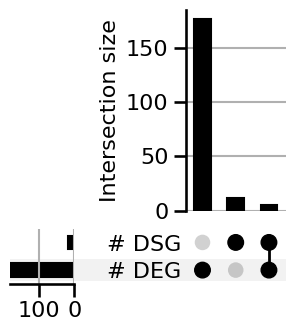

In [12]:
# @markdown **Upsetplot of sets of DEGs and DSGs:** To compare the set of differentially expressed genes (DEGs) and the set of differentially spliced genes (DSGs), both sets are visualised as Upsetplot to showcase their differences and similiarties.

# @markdown **Save upset plot:**
save_fig = True # @param {type:"boolean"}

from crecerelle.plotting_utils import plot_deg_dsg_upsetplot

plot_deg_dsg_upsetplot(
    sig_rank_genes_groups_df,
    sig_rank_spl_introns_df,
    save_fig=save_fig,
    dataset_name=settings["dataset_name"],
    group_id_GE=group_id_GE,
    group_id_TU=group_id_TU,
    tax_level=tax_level,
)


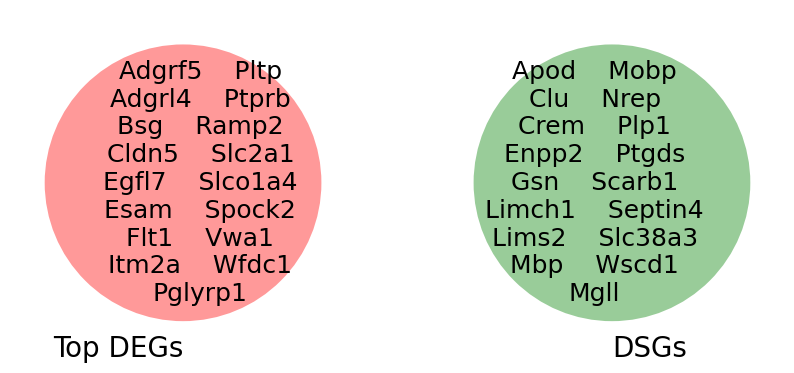

In [13]:
# @markdown **Venn diagram of DSGs and top ranked DSGs:** To compare the intersection of identified DSG with an equally sized of top ranked DEGs, a Venn diagram is generated

# @markdown **Save Venn diagram:**
save_fig = True # @param {type:"boolean"}

from crecerelle.plotting_utils import plot_deg_dsg_venn_diagramm

plot_deg_dsg_venn_diagramm(
    sig_rank_genes_groups_df,
    sig_rank_spl_introns_df,
    save_fig=save_fig,
    dataset_name=settings["dataset_name"],
    group_id_GE=group_id_GE,
    group_id_TU=group_id_TU,
    tax_level=tax_level,
)

In [14]:
# 5' Splice site (Donor +)
# 3' Splice site (Acceptor - )
adata_TU_tissue.uns["rank_intron_groups_groups"]["names"][group_id_TU]

array(['Septin4_chr11_87583920_+', 'Apod_chr16_31311165_-',
       'Scarb1_chr5_125277866_-', 'Enpp2_chr15_54850128_-',
       'Lims2_chr18_31941739_+', 'Lims2_chr18_31954435_+',
       'Enpp2_chr15_54919699_-', 'Lims2_chr18_31956257_+',
       'Nrep_chr18_33463420_-', 'Mbp_chr18_82572824_+',
       'Slc38a3_chr9_107659245_-', 'Mobp_chr9_120173150_+',
       'Limch1_chr5_66969075_+', 'Crem_chr18_3273579_-',
       'Mgll_chr6_88725700_+', 'Gsn_chr2_35283904_+',
       'Clu_chr14_65971731_+', 'Ptgds_chr2_25466832_-',
       'Wscd1_chr11_71759577_+', 'Plp1_chrX_136833267_+',
       'Mbp_chr18_82584111_+'], dtype=object)

/usr/local/lib/python3.12/dist-packages/crecerelle/plotting_utils.py:2020: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax42.set_xticklabels(dsg_gene_names)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


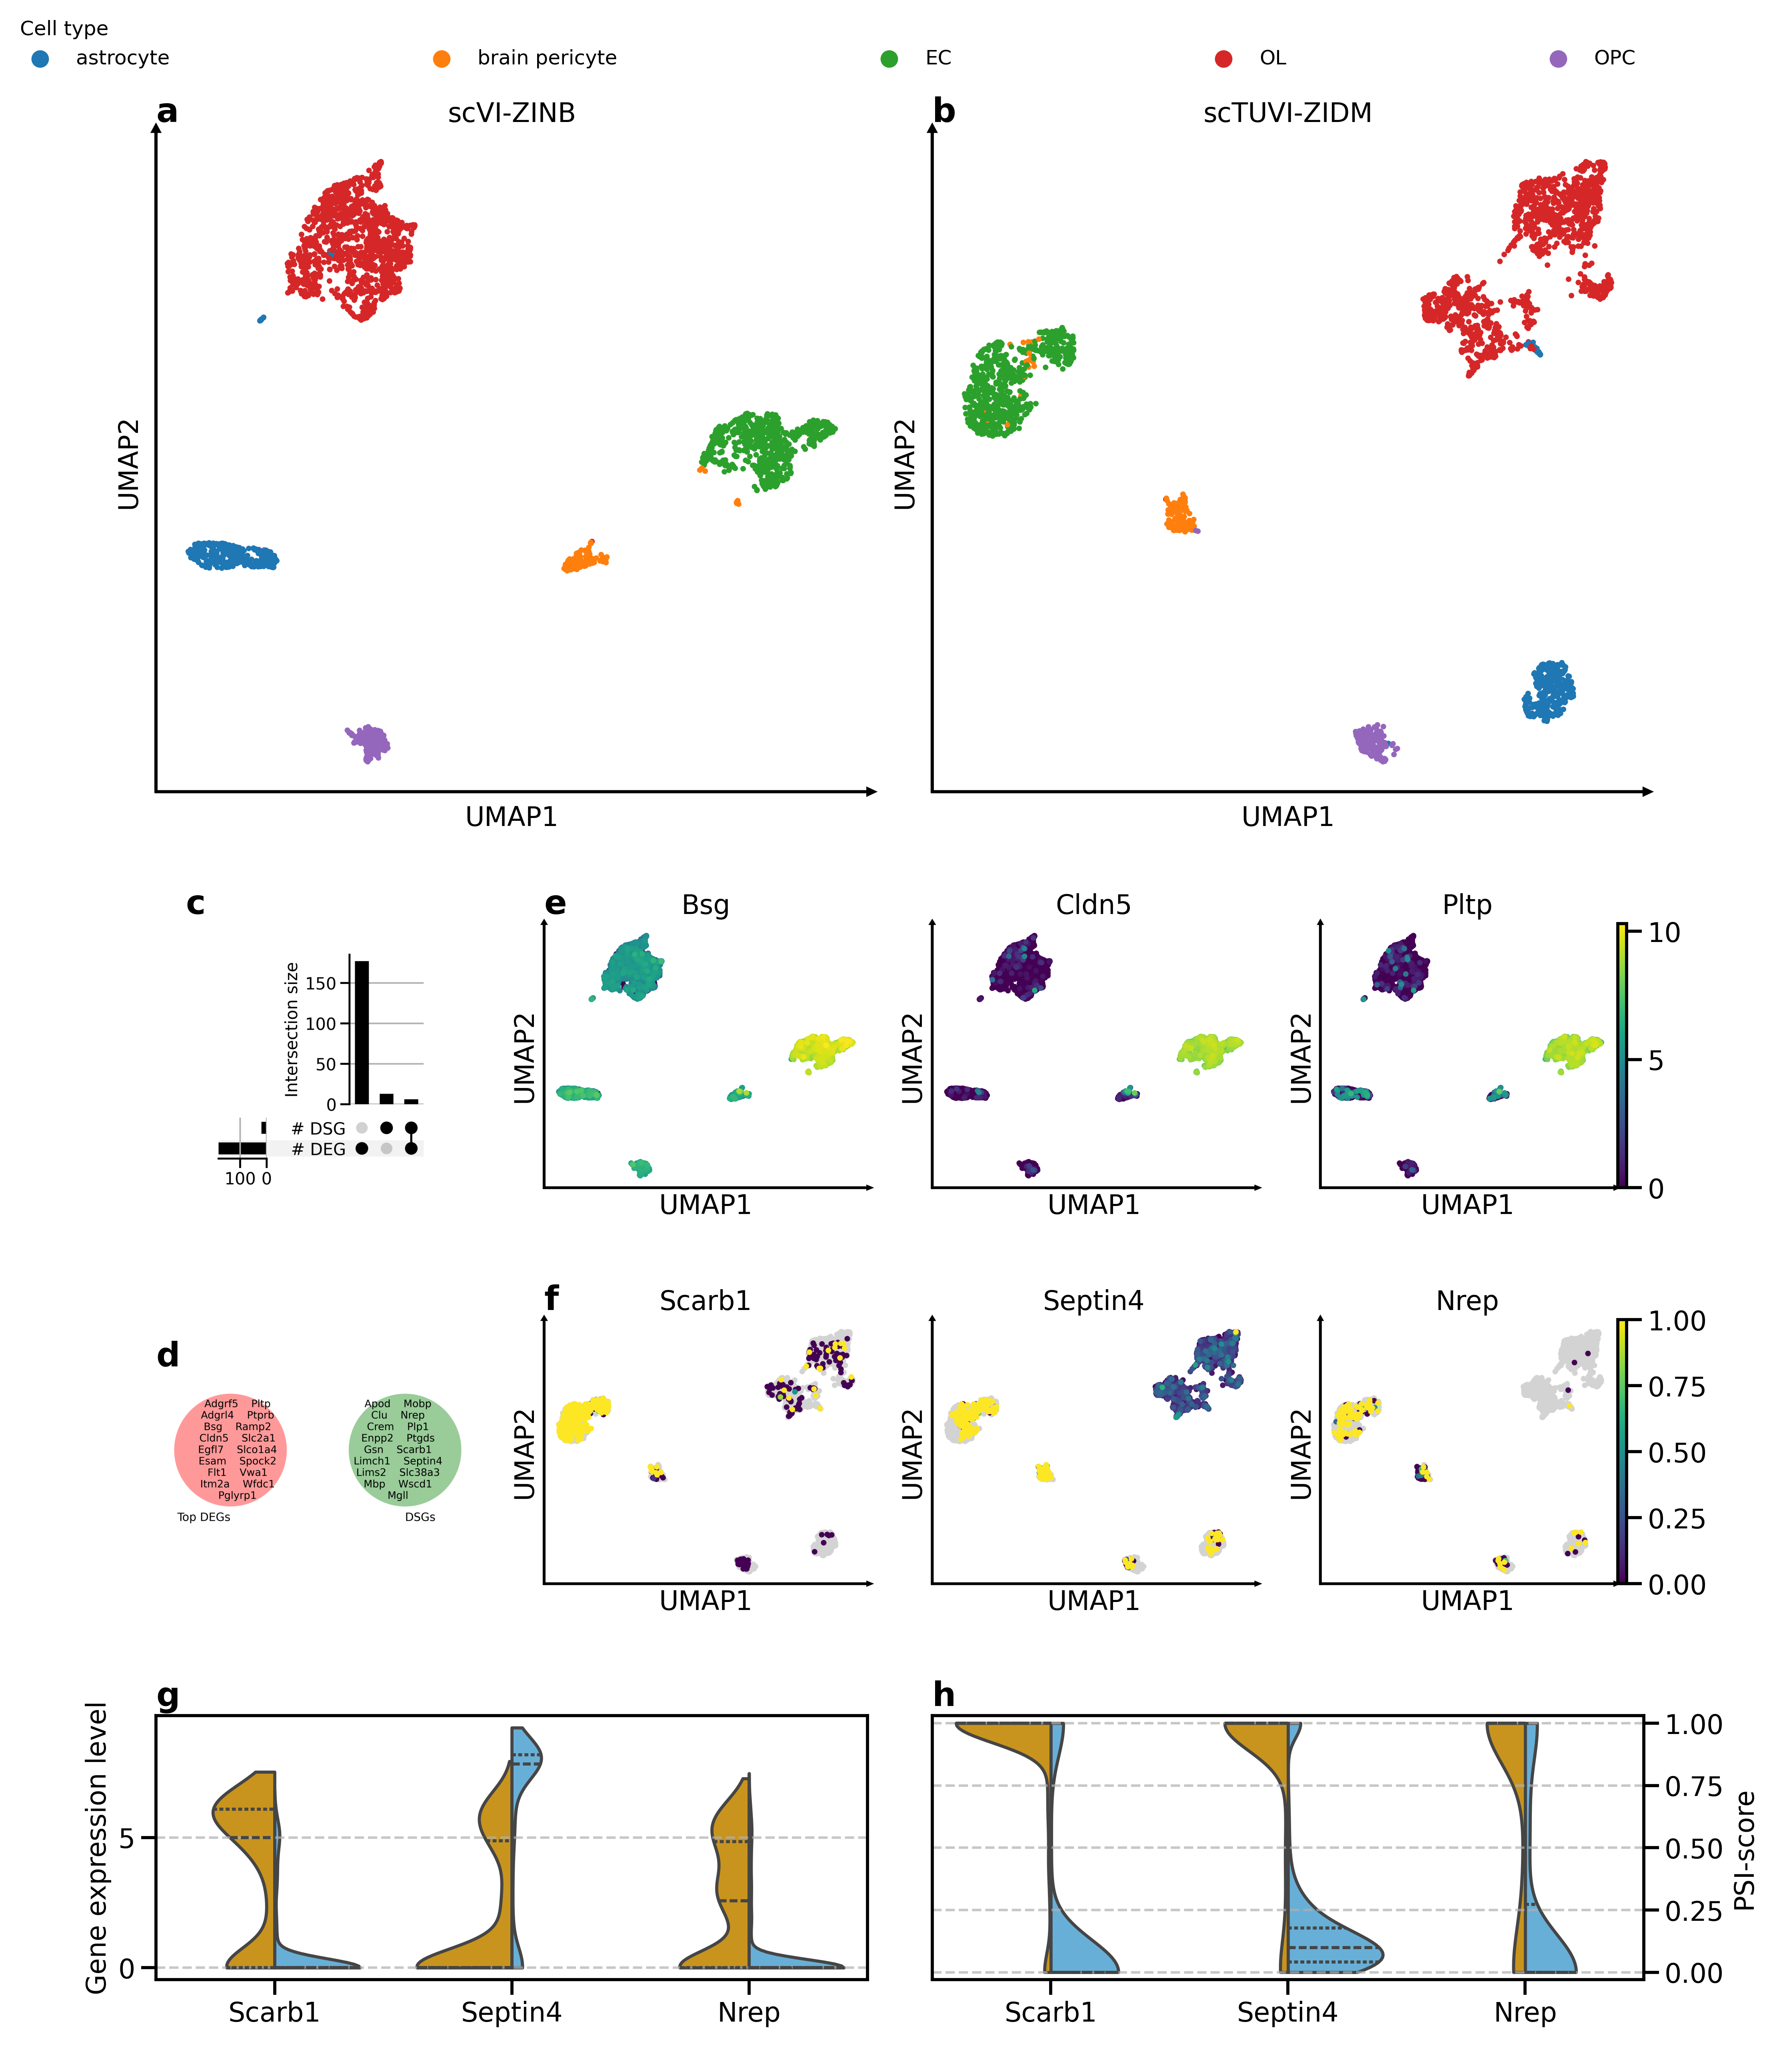

In [15]:
# @markdown **Plot the marker analysis:**

# @markdown **Save figure:**
save_fig = True # @param {type:"boolean"}
file_suffix = "svg" # @param ["pdf", "png", "svg"]

from crecerelle.plotting_utils import plot_marker_analysis_scvi_sctuvi
plot_marker_analysis_scvi_sctuvi(
        adata_objects=(adata_GE_tissue, adata_TU_tissue),
        likelihoods=(likelihood_GE, likelihood_TU),
        cluster_group_ids=(group_id_GE, group_id_TU),
        dsg_exp_df=dsg_exp_df_long,
        dsg_psi_df=dsg_psi_df_long,
        top_degs=top_degs,
        top_dsgs=top_dsgs,
        dsg_gene_names=dsg_gene_names,
        umap_color_key_display=settings['cell_type_key'],
        taxonomy_level=tax_level,
        save_fig=save_fig,
        dataset_name=settings["dataset_name"],
        file_suffix=file_suffix
)